## 1. Introduction
### 1.1 Background

The thyroid gland plays an important role in regulating metabolism, growth and several physiological processes through the production of thyroxine (T4) and triiodothyronine (T3), under the regulatory influence of thyroid-stimulating hormone (TSH). Thyroid dysfunction occurs across a spectrum ranging from overt hypothyroidism and hyperthyroidism to subclinical disease. Hypothyroidism is associated with insufficient thyroid hormone activity, whereas hyperthyroidism results from excessive thyroid hormone production or action. In subclinical thyroid dysfunction, TSH may be abnormal while circulating thyroid hormone concentrations remain within reference ranges [1–3].

Diagnosis of thyroid dysfunction follows established clinical protocols involving assessment of symptoms and medical history, physical examination and biochemical thyroid-function testing. TSH is commonly used as the initial biochemical test, with thyroid hormones such as free T4 and T3 used to further characterize thyroid function [1,2]. Where clinically indicated, additional investigations such as thyroid antibodies, ultrasonography and radionuclide imaging may be used to establish the underlying cause or evaluate structural thyroid disease [2,3]. Thyroid ultrasound is particularly important in the assessment of nodules, with systems such as the American College of Radiology Thyroid Imaging Reporting and Data System (ACR TI-RADS) providing standardized imaging-based risk stratification [4].

The clinical spectrum of thyroid disease extends beyond functional abnormalities. Structural thyroid disease and, less commonly, thyroid malignancy may coexist with or present alongside abnormal thyroid function, including hyperthyroidism [5]. Consequently, classification as hyperthyroid or hypothyroid does not by itself establish the underlying cause of thyroid dysfunction, and biochemical findings should be interpreted within the broader clinical and diagnostic context.

The scope of this project is constrained by the UCI ANN-Thyroid dataset, which defines three outcome classes: Hyperthyroidism, Hypothyroidism and Normal thyroid function [6]. The dataset does not provide separate outcome classes for subclinical hyperthyroidism or subclinical hypothyroidism, nor does it contain the imaging, cytological or histopathological information required to assess thyroid nodules or malignancy. Accordingly, the project focuses specifically on machine-learning classification of the three thyroid-function categories represented in the dataset and does not attempt to model the full clinical spectrum or underlying aetiology of thyroid disease.

### 1.2 Problem Statement

Established protocols for diagnosing thyroid disorders combine clinical assessment and thyroid-function testing, with imaging and other investigations used when clinically indicated. Diagnosis can nevertheless be challenging because thyroid disorders may have overlapping clinical presentations and require interpretation of multiple clinical and laboratory findings. Machine learning may complement these established processes by integrating available variables to support consistent thyroid-function classification. This project therefore develops a model to classify Hyperthyroid, Hypothyroid and Normal thyroid function, while subclinical disease and imaging-based assessment remain outside its scope due to limitations of the ANN-Thyroid dataset.

### 1.3 Key Questions

Can machine-learning models accurately classify patients into Hyperthyroid, Hypothyroid and Normal thyroid-function categories using the demographic, clinical and laboratory variables available in the ANN-Thyroid dataset?
Which clinical and laboratory features contribute most strongly to distinguishing the three thyroid-function classes?
Which supervised machine-learning algorithm provides the strongest and most balanced multiclass classification performance?

### 1.4 Success Metrics

Given the class imbalance in the ANN-Thyroid dataset, performance will be assessed using metrics that reflect classification across all three classes rather than overall accuracy alone. The project will target:

Macro F1-score ≥ 0.90

Balanced Accuracy ≥ 0.90

Recall ≥ 0.85 for both Hyperthyroid and Hypothyroid classes

## 2. Data Understanding

 This section introduces the dataset, examines its structure, and performs an initial quality assessment to identify potential issues that may require attention during data preparation. The goal is to establish a clear understanding of the available data before conducting exploratory analysis.

### 2.1 Import Libraries

The project relies on several Python libraries for data manipulation, visualization, statistical analysis, and machine learning. Importing these libraries at the beginning of the notebook ensures that all required tools are available for the subsequent analysis.

In [110]:

# Import Libraries

# Core Libraries
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Statistical Analysis
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

# Machine Learning - Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
#Model validation 
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

#Tuning
from sklearn.model_selection import RandomizedSearchCV

# Model Interpretation
from sklearn.inspection import permutation_importance

# Notebook Settings

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2.2 Load Dataset

The next step is to load the thyroid disease dataset into a Pandas DataFrame for inspection and analysis.


In [3]:
# Load dataset
df = pd.read_csv("data/thyroid.csv")

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}")

# Display the first five records
df.head()

Dataset Shape: (7200, 22)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
0,0.7300,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0006,0.0150,0.1200,0.0820,0.1460,3
1,0.2400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0003,0.0300,0.1430,0.1330,0.1080,3
2,0.4700,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0019,0.0240,0.1020,0.1310,0.0780,3
3,0.6400,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0009,0.0170,0.0770,0.0900,0.0850,3
4,0.2300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0003,0.0260,0.1390,0.0900,0.1530,3


### 2.3 Dataset Source

This study uses the ANN-Thyroid dataset obtained from the UCI Machine Learning Repository, a widely used benchmark repository for machine learning research. The dataset contains patient records comprising demographic information, clinical indicators, treatment history, laboratory measurements, and thyroid diagnosis labels. The original dataset consists of separate training and testing files that have been combined into a single dataset for this analysis.

### 2.4 Dataset Overview

The following inspection provides a high-level understanding of the dataset, including its dimensions, variables, data types, and memory usage.

In [4]:
# Dataset dimensions.
print (f"Rows: {df.shape[0]}")
print (f"Columns: {df.shape[1]}")

# Column names
df.columns

Rows: 7200
Columns: 22


Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U',
       'FTI', 'class'],
      dtype='str')

The dataset contains 7200 observations and 22 features.

In [5]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        7200 non-null   float64
 1   sex                        7200 non-null   int64  
 2   on_thyroxine               7200 non-null   int64  
 3   query_on_thyroxine         7200 non-null   int64  
 4   on_antithyroid_medication  7200 non-null   int64  
 5   sick                       7200 non-null   int64  
 6   pregnant                   7200 non-null   int64  
 7   thyroid_surgery            7200 non-null   int64  
 8   I131_treatment             7200 non-null   int64  
 9   query_hypothyroid          7200 non-null   int64  
 10  query_hyperthyroid         7200 non-null   int64  
 11  lithium                    7200 non-null   int64  
 12  goitre                     7200 non-null   int64  
 13  tumor                      7200 non-null   int64  
 14  hyp

The dataset contains 7,200 observations and 22 variables. It comprises 6 continuous variables and 16 integer variables, including the target variable (class). The dataset is well-structured and suitable for exploratory data analysis, preprocessing, and multiclass machine learning classification.

In [6]:
# Display five random observations
df.sample(5, random_state=42)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
3098,0.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0024,0.0208,0.1120,0.1250,0.0900,3
2531,0.3500,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0012,0.0270,0.1370,0.1190,0.1150,3
4071,0.4600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0013,0.0201,0.0730,0.0770,0.0950,3
1287,0.7300,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.0039,0.0090,0.0620,0.0540,0.1150,3
2540,0.7100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0006,0.0208,0.1190,0.1080,0.1100,3


In [10]:
#Descriptive statistics for numerical variables.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7200.0000,0.5205,0.1893,0.0100,0.3700,0.5500,0.6700,0.9700
sex,7200.0000,0.3043,0.4601,0.0000,0.0000,0.0000,1.0000,1.0000
on_thyroxine,7200.0000,0.1306,0.3369,0.0000,0.0000,0.0000,0.0000,1.0000
query_on_thyroxine,7200.0000,0.0154,0.1232,0.0000,0.0000,0.0000,0.0000,1.0000
on_antithyroid_medication,7200.0000,0.0128,0.1123,0.0000,0.0000,0.0000,0.0000,1.0000
sick,7200.0000,0.0383,0.1920,0.0000,0.0000,0.0000,0.0000,1.0000
pregnant,7200.0000,0.0108,0.1035,0.0000,0.0000,0.0000,0.0000,1.0000
thyroid_surgery,7200.0000,0.0140,0.1176,0.0000,0.0000,0.0000,0.0000,1.0000
I131_treatment,7200.0000,0.0168,0.1286,0.0000,0.0000,0.0000,0.0000,1.0000
query_hypothyroid,7200.0000,0.0656,0.2475,0.0000,0.0000,0.0000,0.0000,1.0000


The binary variables have means close to 0, indicating that most clinical conditions are relatively uncommon in the dataset. The continuous variable age has a mean of 0.52 with moderate variability (SD = 0.19), while the wide ranges observed in the laboratory measurements should be further examined for potential outliers during exploratory data analysis.

### 2.5 Dataset Dictionary

The dataset contains demographic variables, treatment-related variables, clinical indicators, laboratory measurements, and a multiclass target variable. The table below provides a description of each variable included in the analysis.

In [12]:
# Data Dictionary
data_dictionary = pd.DataFrame({
    "Feature": [
        "age", "sex", "on_thyroxine", "query_on_thyroxine",
        "on_antithyroid_medication", "sick", "pregnant",
        "thyroid_surgery", "I131_treatment",
        "query_hypothyroid", "query_hyperthyroid",
        "lithium", "goitre", "tumor",
        "hypopituitary", "psych",
        "TSH", "T3", "TT4", "T4U", "FTI",
        "class"
    ],

    "Type": [
        "Numeric", "Binary", "Binary", "Binary",
        "Binary", "Binary", "Binary",
        "Binary", "Binary",
        "Binary", "Binary",
        "Binary", "Binary", "Binary",
        "Binary", "Binary",
        "Numeric", "Numeric", "Numeric", "Numeric", "Numeric",
        "Categorical"
    ],

    "Category": [
        "Demographic", "Demographic",
        "Treatment", "Treatment",
        "Treatment", "Clinical", "Clinical",
        "Treatment", "Treatment",
        "Clinical", "Clinical",
        "Medication", "Clinical", "Clinical",
        "Clinical", "Clinical",
        "Laboratory", "Laboratory", "Laboratory",
        "Laboratory", "Laboratory",
        "Target"
    ],

    "Description": [
        "Normalized patient age.",
        "Patient sex (0 = Female, 1 = Male).",
        "Whether the patient is receiving thyroxine treatment.",
        "Whether thyroxine treatment was queried.",
        "Whether the patient is receiving antithyroid medication.",
        "Whether the patient was recorded as sick.",
        "Pregnancy status.",
        "History of thyroid surgery.",
        "History of radioactive iodine (I131) treatment.",
        "Whether hypothyroidism was suspected.",
        "Whether hyperthyroidism was suspected.",
        "History of lithium medication.",
        "Presence of goitre.",
        "Presence of a thyroid tumor.",
        "Presence of hypopituitarism.",
        "Presence of a psychological condition.",
        "Normalized Thyroid Stimulating Hormone (TSH) level.",
        "Normalized Triiodothyronine (T3) level.",
        "Normalized Total Thyroxine (TT4) level.",
        "Normalized Thyroxine Uptake (T4U) level.",
        "Normalized Free Thyroxine Index (FTI).",
        "Target variable (1 = Hyperthyroid, 2 = Hypothyroid, 3 = Normal)."
    ]
})

data_dictionary

,Feature,Type,Category,Description
0,age,Numeric,Demographic,Normalized patient age.
1,sex,Binary,Demographic,"Patient sex (0 = Female, 1 = Male)."
2,on_thyroxine,Binary,Treatment,Whether the patient is receiving thyroxine tre...
3,query_on_thyroxine,Binary,Treatment,Whether thyroxine treatment was queried.
4,on_antithyroid_medication,Binary,Treatment,Whether the patient is receiving antithyroid m...
5,sick,Binary,Clinical,Whether the patient was recorded as sick.
6,pregnant,Binary,Clinical,Pregnancy status.
7,thyroid_surgery,Binary,Treatment,History of thyroid surgery.
8,I131_treatment,Binary,Treatment,History of radioactive iodine (I131) treatment.
9,query_hypothyroid,Binary,Clinical,Whether hypothyroidism was suspected.


### 2.6 Initial Data Quality Assessment

Before exploring relationships within the data, it is important to assess its overall quality. The following checks identify common data quality issues that may affect subsequent analyses. No modifications are made at this stage; the objective is only to identify potential issues.



#### 2.6.1 Missing Values

In [13]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values

,Missing Values,Percentage (%)
age,0,0.0000
sex,0,0.0000
on_thyroxine,0,0.0000
query_on_thyroxine,0,0.0000
on_antithyroid_medication,0,0.0000
sick,0,0.0000
pregnant,0,0.0000
thyroid_surgery,0,0.0000
I131_treatment,0,0.0000
query_hypothyroid,0,0.0000


No missing values found in the dataset.

### 2.6.2 Duplicate Records.

In [14]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 71


The dataset contains 71 duplicate records. These duplicates may introduce bias by overrepresenting certain observations during model training and evaluation. They will be reviewed and removed during the data cleaning to ensure data quality.

### 2.6.3 Data Types

In [15]:
df.dtypes.to_frame(name="Data Type")

,Data Type
age,float64
sex,int64
on_thyroxine,int64
query_on_thyroxine,int64
on_antithyroid_medication,int64
sick,int64
pregnant,int64
thyroid_surgery,int64
I131_treatment,int64
query_hypothyroid,int64


The dataset contains appropriate data types for analysis. Continuous variables are stored as float64, while binary predictors and the target variable are stored as int64. No data type inconsistencies were identified.

### 2.6.4 Unique values per Feature

In [17]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
age,98
sex,2
on_thyroxine,2
query_on_thyroxine,2
on_antithyroid_medication,2
sick,2
pregnant,2
thyroid_surgery,2
I131_treatment,2
query_hypothyroid,2


The dataset contains a mix of binary, categorical, and numerical variables. All binary features have two unique values, confirming their binary encoding, while the target variable contains three distinct classes corresponding to the thyroid diagnosis categories. The numerical features exhibit varying levels of granularity, with laboratory measurements such as FTI (466 unique values), TSH (326), and TT4 (272) showing high variability, whereas T3 (85) and age (98) have comparatively fewer unique values. The presence of numerous unique values among the continuous variables suggests that they retain sufficient variability to provide meaningful discriminatory information for machine learning models.

### 2.6.5 Validate Binary Features

In [18]:
binary_features = [
    "sex",
    "on_thyroxine",
    "query_on_thyroxine",
    "on_antithyroid_medication",
    "sick",
    "pregnant",
    "thyroid_surgery",
    "I131_treatment",
    "query_hypothyroid",
    "query_hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych"
]

binary_validation = pd.DataFrame({
    "Unique Values": [sorted(df[col].unique()) for col in binary_features]
}, index=binary_features)

binary_validation

,Unique Values
sex,"[0, 1]"
on_thyroxine,"[0, 1]"
query_on_thyroxine,"[0, 1]"
on_antithyroid_medication,"[0, 1]"
sick,"[0, 1]"
pregnant,"[0, 1]"
thyroid_surgery,"[0, 1]"
I131_treatment,"[0, 1]"
query_hypothyroid,"[0, 1]"
query_hyperthyroid,"[0, 1]"


All binary features contain only the expected values of 0 and 1, indicating that there are no invalid or inconsistent encodings within these variables. This confirms that the binary attributes have been encoded correctly and do not require additional cleaning or transformation before analysis.

### 2.6.6 Validate Target Labels

In [19]:
print("Target Classes:")

df["class"].value_counts().sort_index()

Target Classes:


class
1     166
2     368
3    6666
Name: count, dtype: int64

The target variable exhibits a highly imbalanced class distribution. The Normal class (Class 3) accounts for 6,666 observations (92.58%), while Hypothyroidism (Class 2) and Hyperthyroidism (Class 1) comprise only 368 (5.11%) and 166 (2.31%) observations, respectively. This imbalance suggests that a model optimized solely for overall accuracy may become biased toward predicting the majority class, resulting in poor detection of the minority disease classes. Consequently, model performance will be evaluated using metrics that account for class imbalance, such as Macro F1-score, Balanced Accuracy, and class-specific Precision, Recall, and F1-score, rather than relying on accuracy alone.

### 2.6.7 Data Quality Summary

-No missing values were detected, indicating that the dataset is complete and does not require missing value imputation.

-All variables are stored using appropriate data types, with continuous features as float64 and binary/categorical features as int64.

-Binary variables are correctly encoded using only the expected values (0 and 1), with no invalid encodings identified.

-The target variable contains the expected three classes representing Hyperthyroidism, Hypothyroidism, and Normal thyroid function.

-A total of 71 duplicate records were identified and will be addressed during the data cleaning stage.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Introduction

Exploratory Data Analysis (EDA) is conducted to understand the characteristics of the dataset before model development. The analysis aims to examine feature distributions, identify relationships among variables, detect potential anomalies, and uncover patterns that may influence thyroid disease classification. Insights obtained from this section will guide data preparation, feature engineering, model selection, and the interpretation of model performance.

The EDA is organized into four components: Target Variable Analysis, Univariate Analysis, Bivariate Analysis, and Multivariate Analysis.


### 3.2 Target Variable Analysis

The target variable is examined first to understand the distribution of thyroid diagnosis classes within the dataset. Assessing the class distribution is important because class imbalance can influence model training and evaluation, particularly in multiclass classification problems.


#### Target Class Distribution

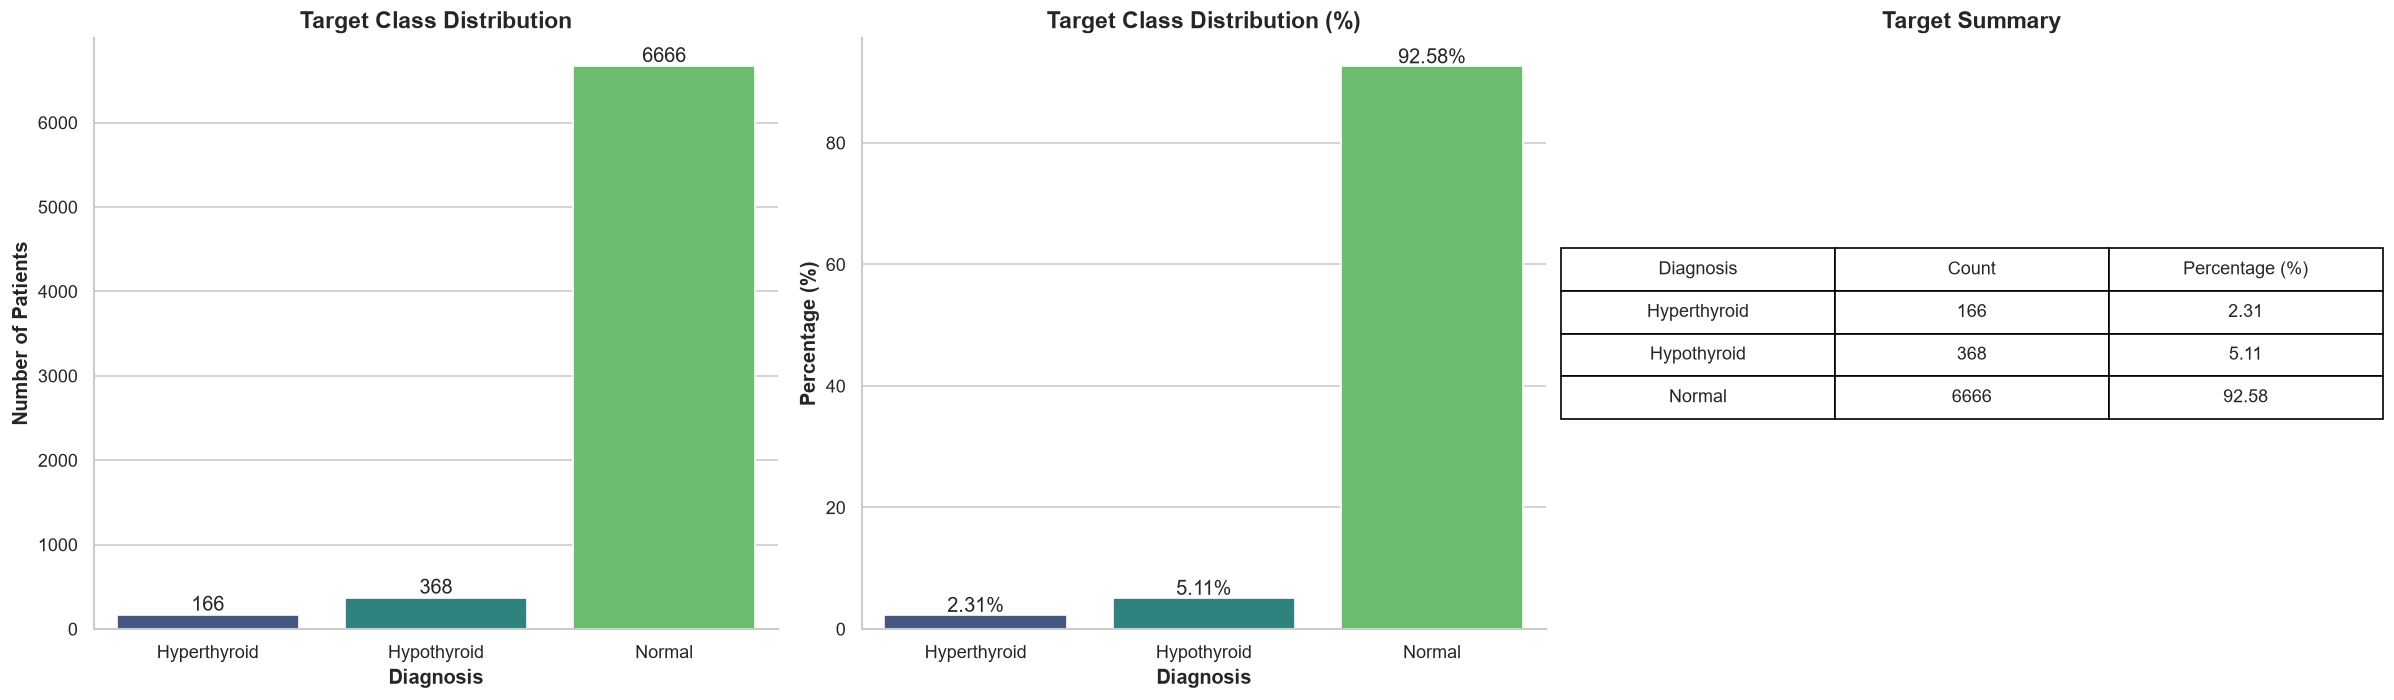

In [ ]:
# Calculate class counts and percentages
class_counts = df["class"].value_counts().sort_index()
class_percentages = (class_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "Diagnosis": ["Hyperthyroid", "Hypothyroid", "Normal"],
    "Count": class_counts.values,
    "Percentage (%)": class_percentages.values
})

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Class Counts
sns.countplot(
    data=df,
    x="class",
    order=[1, 2, 3],
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xticklabels(["Hyperthyroid", "Hypothyroid", "Normal"])

for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

# Plot 2: Percentage Distribution
sns.barplot(
    x=target_summary["Diagnosis"],
    y=target_summary["Percentage (%)"],
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title("Target Class Distribution (%)")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Percentage (%)")

for i, value in enumerate(target_summary["Percentage (%)"]):
    axes[1].text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

# Plot 3: Summary Table
axes[2].axis("off")

table = axes[2].table(
    cellText=target_summary.values,
    colLabels=target_summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

axes[2].set_title("Target Summary")

plt.tight_layout()
plt.show()

The target variable is highly imbalanced, with the Normal class comprising 92.58% of the dataset, compared to only 5.11% for Hypothyroidism and 2.31% for Hyperthyroidism. This distribution indicates that disease cases, particularly Hyperthyroidism, are substantially underrepresented. As a result, machine learning models may become biased toward predicting the Normal class, leading to poor detection of the minority disease classes. Therefore, model performance will be evaluated using metrics that reflect performance across all classes rather than relying solely on overall accuracy.

### 3.3 Univariate Analysis

Univariate analysis examines each feature independently to understand its distribution, variability, and potential anomalies. Numerical variables are assessed using descriptive statistics and distribution plots, while binary variables are summarized using frequency distributions. The insights obtained from this analysis help identify skewness, outliers, and feature characteristics that may influence subsequent preprocessing and model development.

#### 3.3.1 Numerical Variables

##### Summary Statistics

In [26]:
# Numerical features
numerical_features = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

# Summary statistics
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,7200.0000,0.5205,0.1893,0.0100,0.3700,0.5500,0.6700,0.9700
TSH,7200.0000,0.0049,0.0230,0.0000,0.0007,0.0017,0.0027,0.5300
T3,7200.0000,0.0200,0.0075,0.0005,0.0170,0.0201,0.0220,0.1800
TT4,7200.0000,0.1094,0.0360,0.0020,0.0890,0.1070,0.1250,0.6000
T4U,7200.0000,0.0978,0.0191,0.0170,0.0870,0.0970,0.1040,0.2330
FTI,7200.0000,0.1132,0.0361,0.0020,0.0950,0.1110,0.1270,0.6420


##### Skewness

In [27]:
# Calculate skewness
skewness = pd.DataFrame({
    "Skewness": df[numerical_features].skew().round(3)
})

skewness

,Skewness
age,-0.2130
TSH,14.5260
T3,3.4880
TT4,1.5160
T4U,1.2480
FTI,2.3850


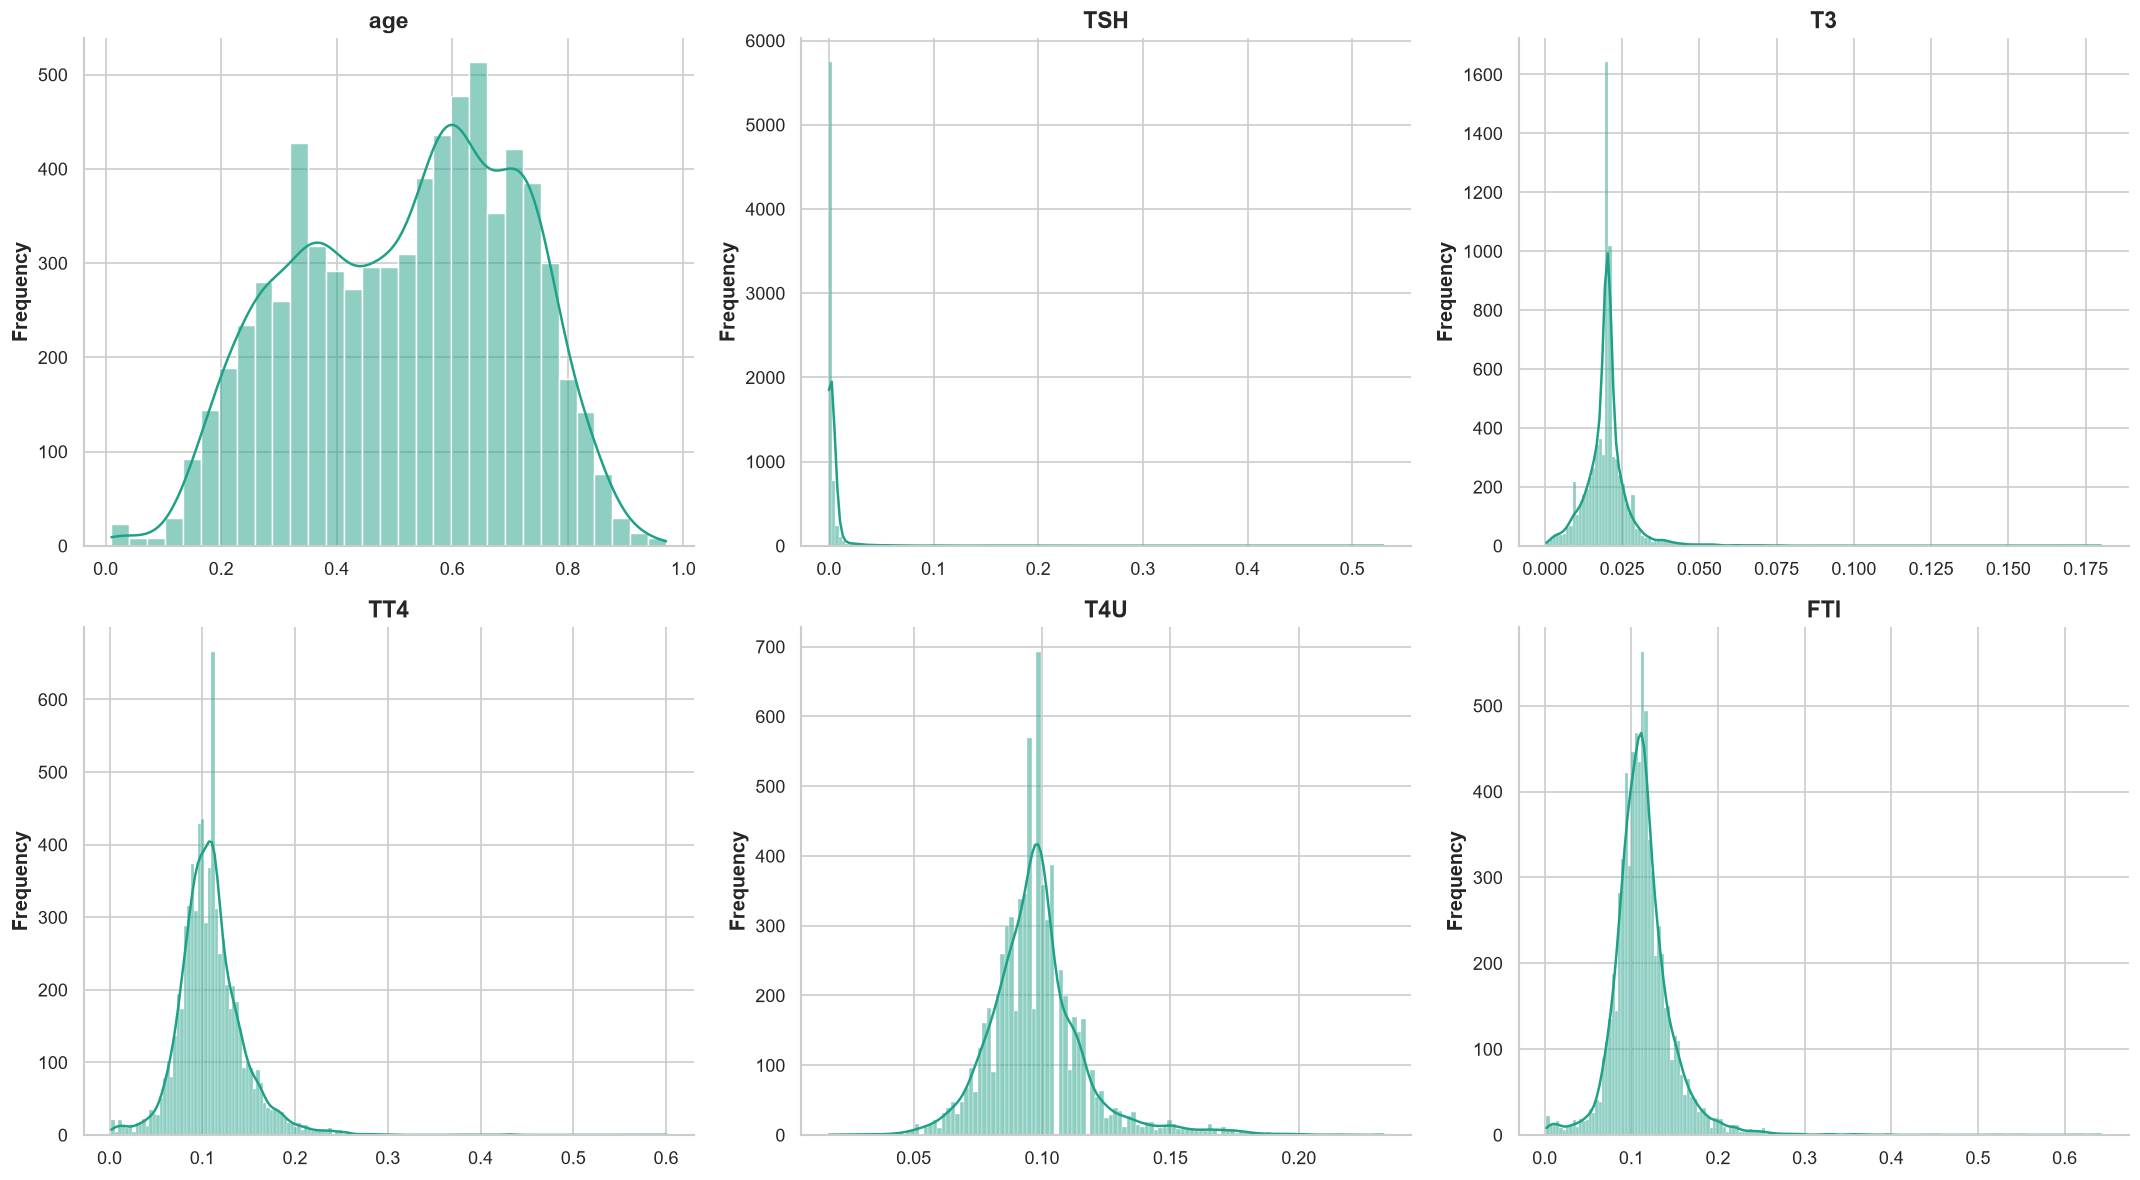

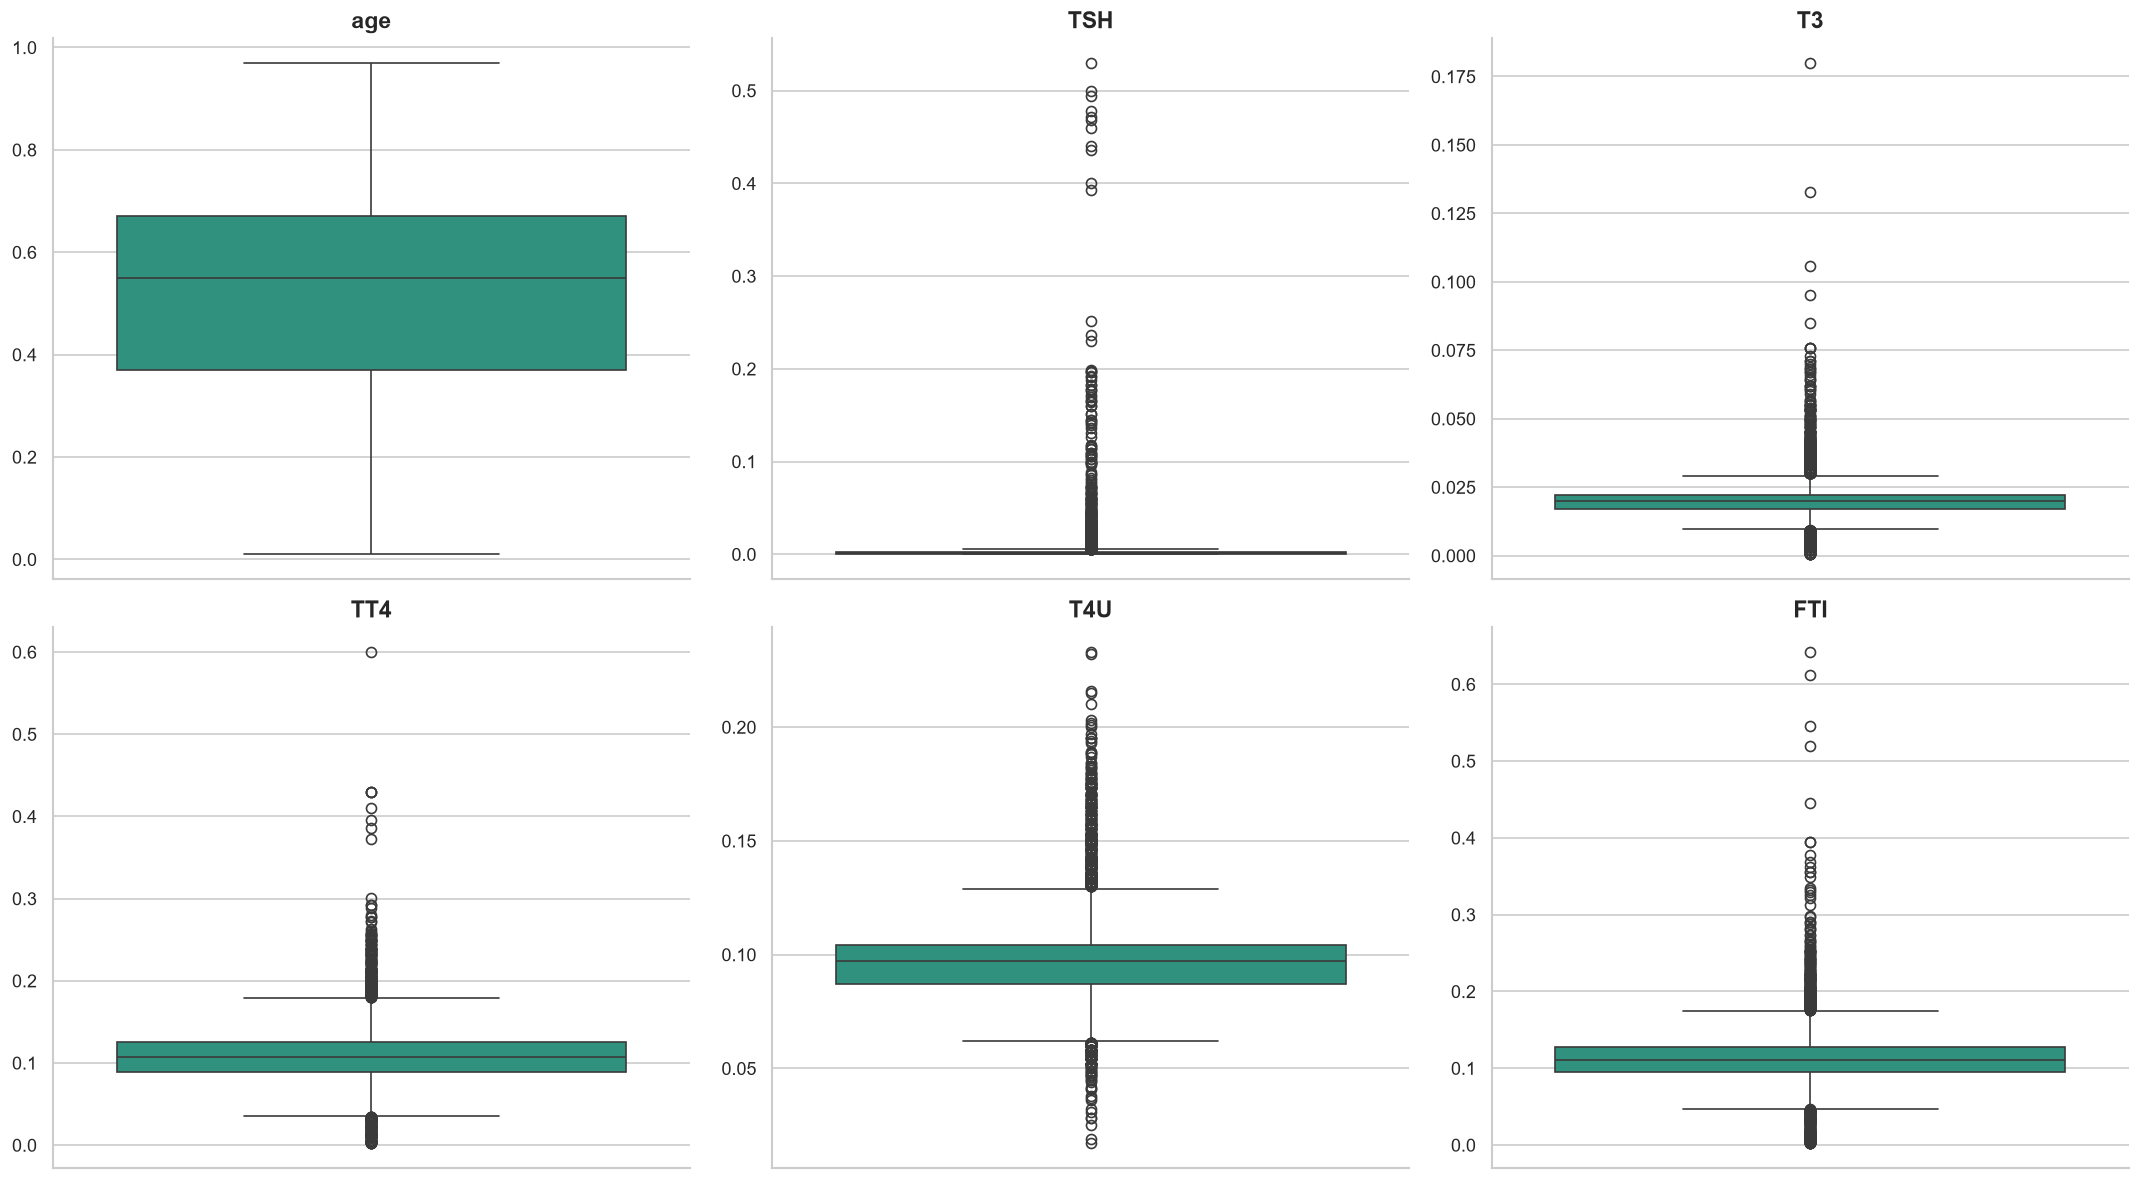

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax,
        color=sns.color_palette("viridis")[3]
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax,
        color=sns.color_palette("viridis")[3]
    )

    ax.set_title(feature)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

The numerical variables exhibit diverse distributional characteristics. The age variable displays a relatively broad distribution with no pronounced skewness, suggesting a good representation of patients across different age groups. In contrast, the laboratory measurements (TSH, T3, TT4, T4U, and FTI) are generally positively skewed, with most observations concentrated within a narrow range and a small number of extreme values extending the upper tails of their distributions. The corresponding boxplots confirm the presence of numerous outliers, particularly for TSH, TT4, and FTI, while age shows comparatively few extreme observations. These outliers are likely to reflect genuine physiological variations rather than data entry errors, given the clinical nature of the dataset. Consequently, they will be retained during preprocessing, and any necessary feature scaling or transformation will be considered during model development rather than removing potentially informative observations.

### Binary Variables

##### Frequency Distribution

In [31]:
binary_features = [
    "sex",
    "on_thyroxine",
    "query_on_thyroxine",
    "on_antithyroid_medication",
    "sick",
    "pregnant",
    "thyroid_surgery",
    "I131_treatment",
    "query_hypothyroid",
    "query_hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych"
]

binary_summary = pd.DataFrame({
    "Count (Yes)": df[binary_features].sum(),
    "Percentage (%)": (df[binary_features].mean()*100).round(2)
})

binary_summary.sort_values(
    by="Percentage (%)",
    ascending=False
)

,Count (Yes),Percentage (%)
sex,2191,30.4300
on_thyroxine,940,13.0600
query_hyperthyroid,495,6.8800
query_hypothyroid,472,6.5600
psych,352,4.8900
sick,276,3.8300
tumor,184,2.5600
I131_treatment,121,1.6800
query_on_thyroxine,111,1.5400
thyroid_surgery,101,1.4000


##### Binary Variables Distribution

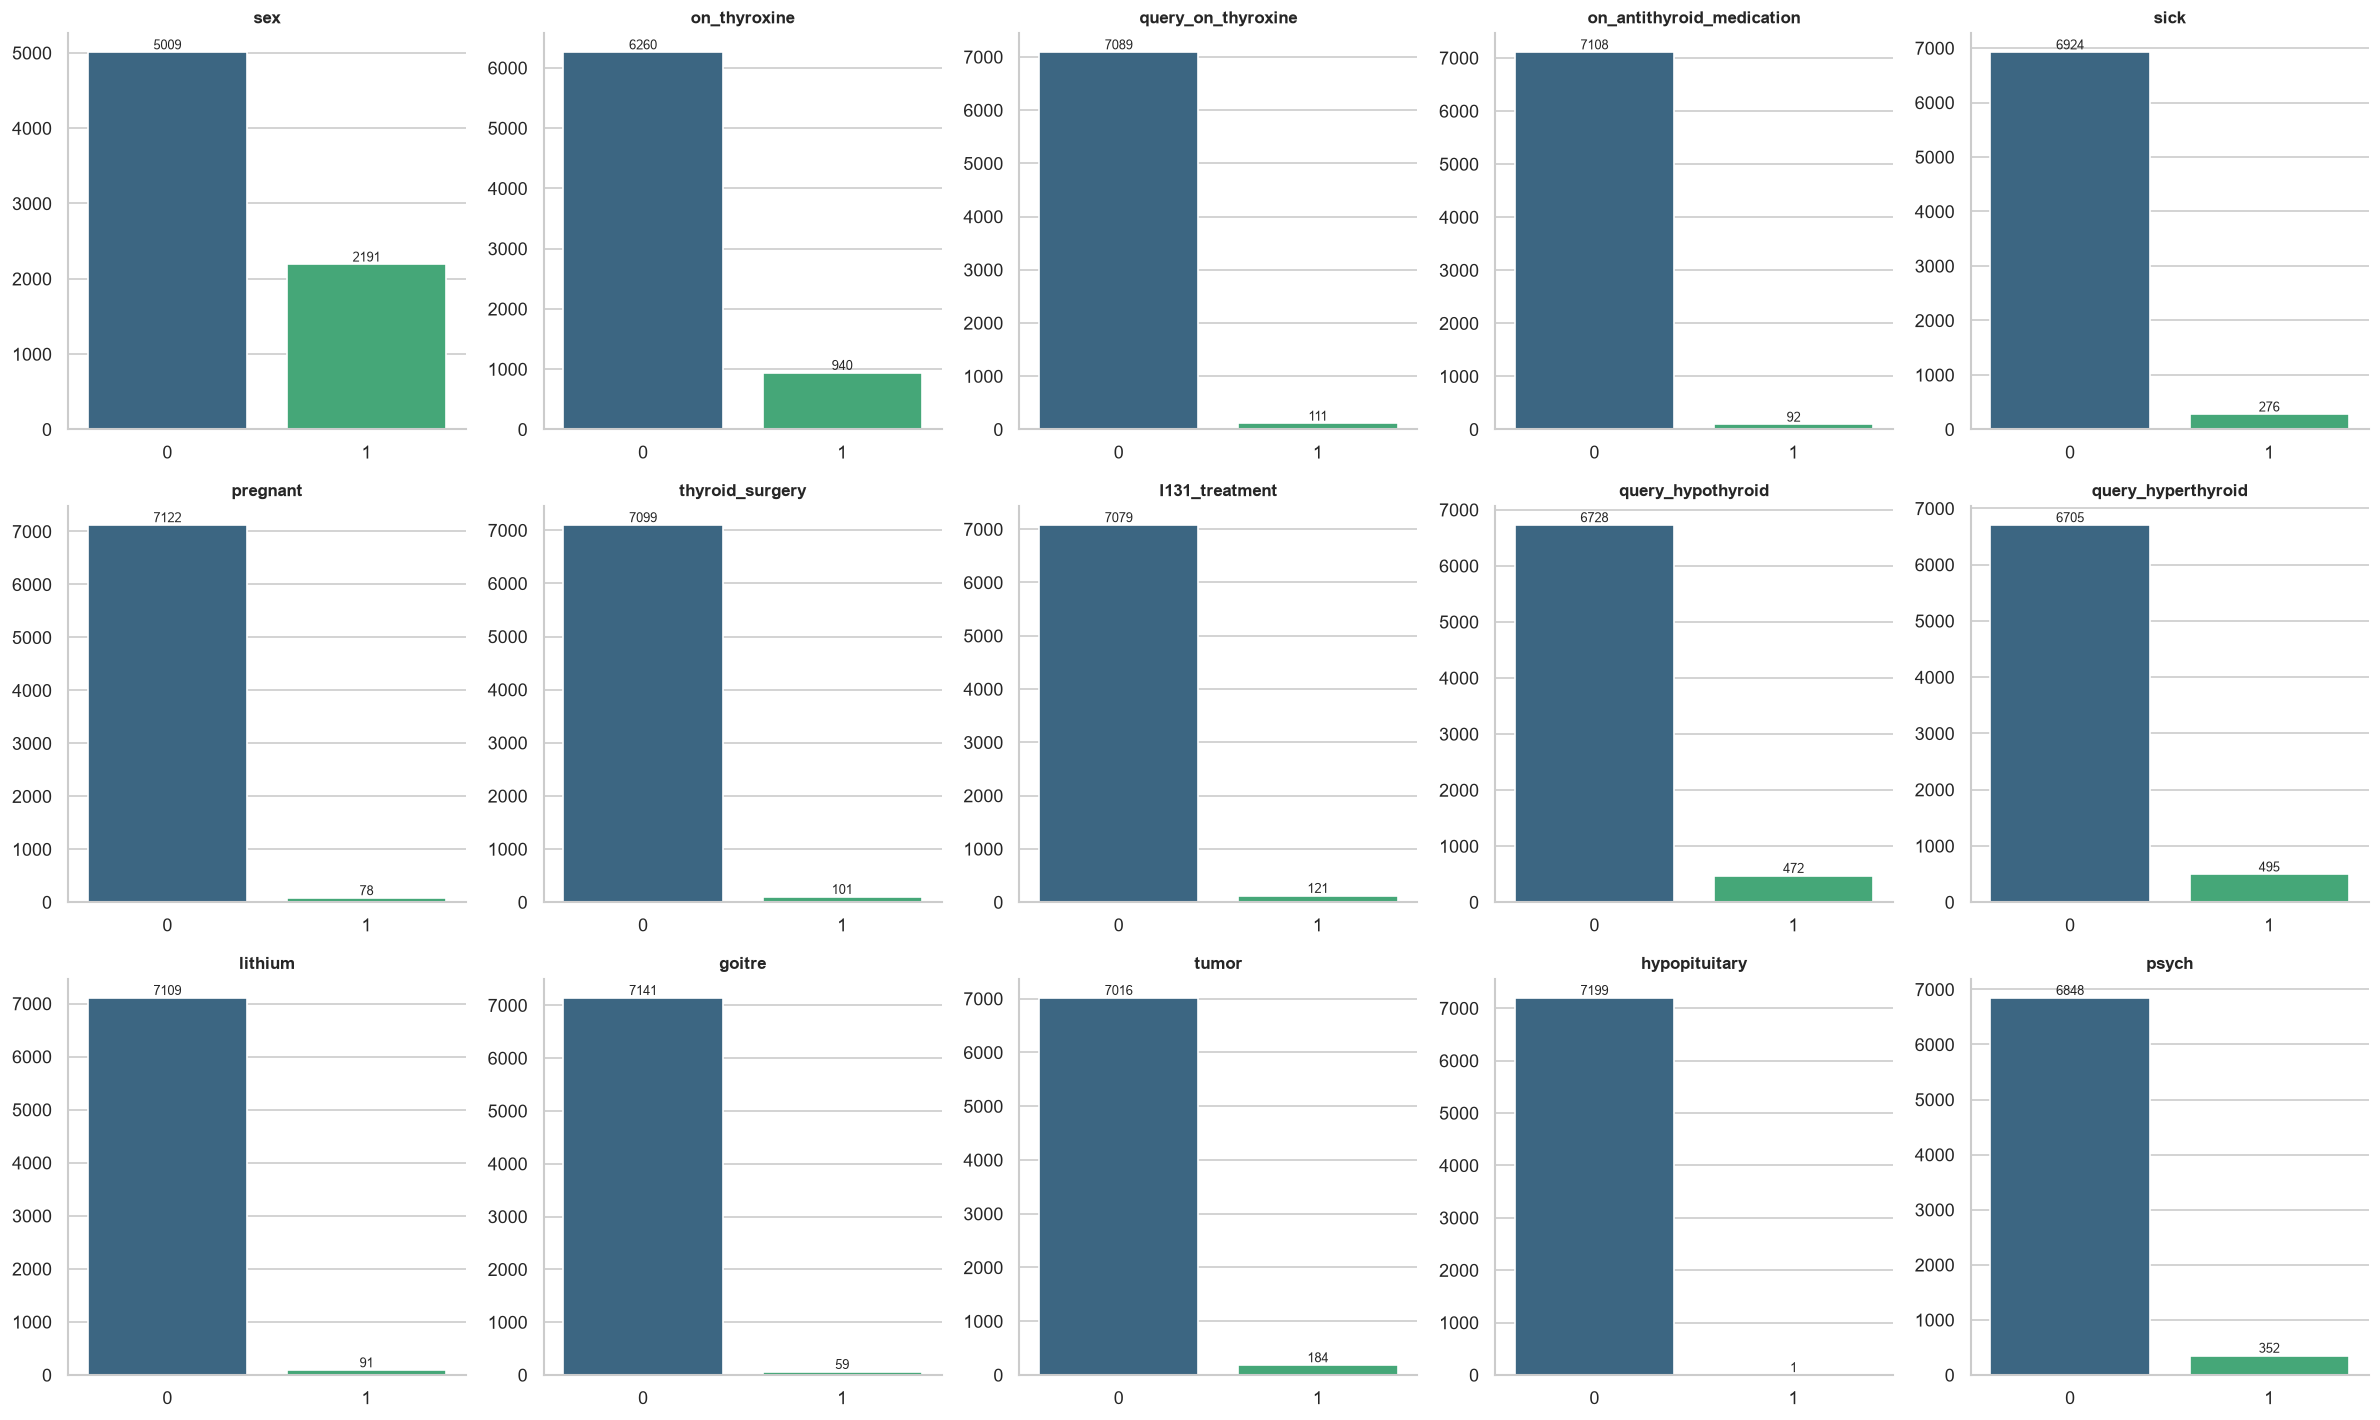

In [32]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for ax, feature in zip(axes.flatten(), binary_features):

    sns.countplot(
        data=df,
        x=feature,
        palette="viridis",
        ax=ax
    )

    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x() + p.get_width()/2,
             p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

The binary variables are predominantly characterized by the absence of the recorded clinical condition or treatment (value = 0), indicating that most patients did not exhibit these characteristics. The most prevalent binary feature is sex, with females (coded as 0) representing the majority of the study population. Among the clinical indicators, query_hyperthyroid (495 cases), query_hypothyroid (472 cases), psych (352 cases), and sick (276 cases) have relatively higher frequencies of positive observations compared to the remaining variables. Conversely, features such as hypopituitary (1 case), goitre (59 cases), pregnant (78 cases), lithium (91 cases), on_antithyroid_medication (92 cases), and thyroid_surgery (101 cases) are extremely rare. The substantial imbalance observed across several binary predictors suggests that while these variables may contain clinically relevant information, some contribute limited variability and may have a smaller influence on model performance.

### Bivariate Analysis

Bivariate analysis examines the relationship between each predictor variable and the target variable. The objective is to identify features that differ significantly across thyroid diagnosis classes and to explore potential associations that may contribute to accurate disease classification. Numerical variables are analysed using comparative distribution plots and statistical tests, while binary variables are evaluated using contingency analysis and tests of association.

#### 3.4.1 Numerical Variables vs Target
For the six laboratory variables and age, we'll compare their distributions across the three thyroid classes.

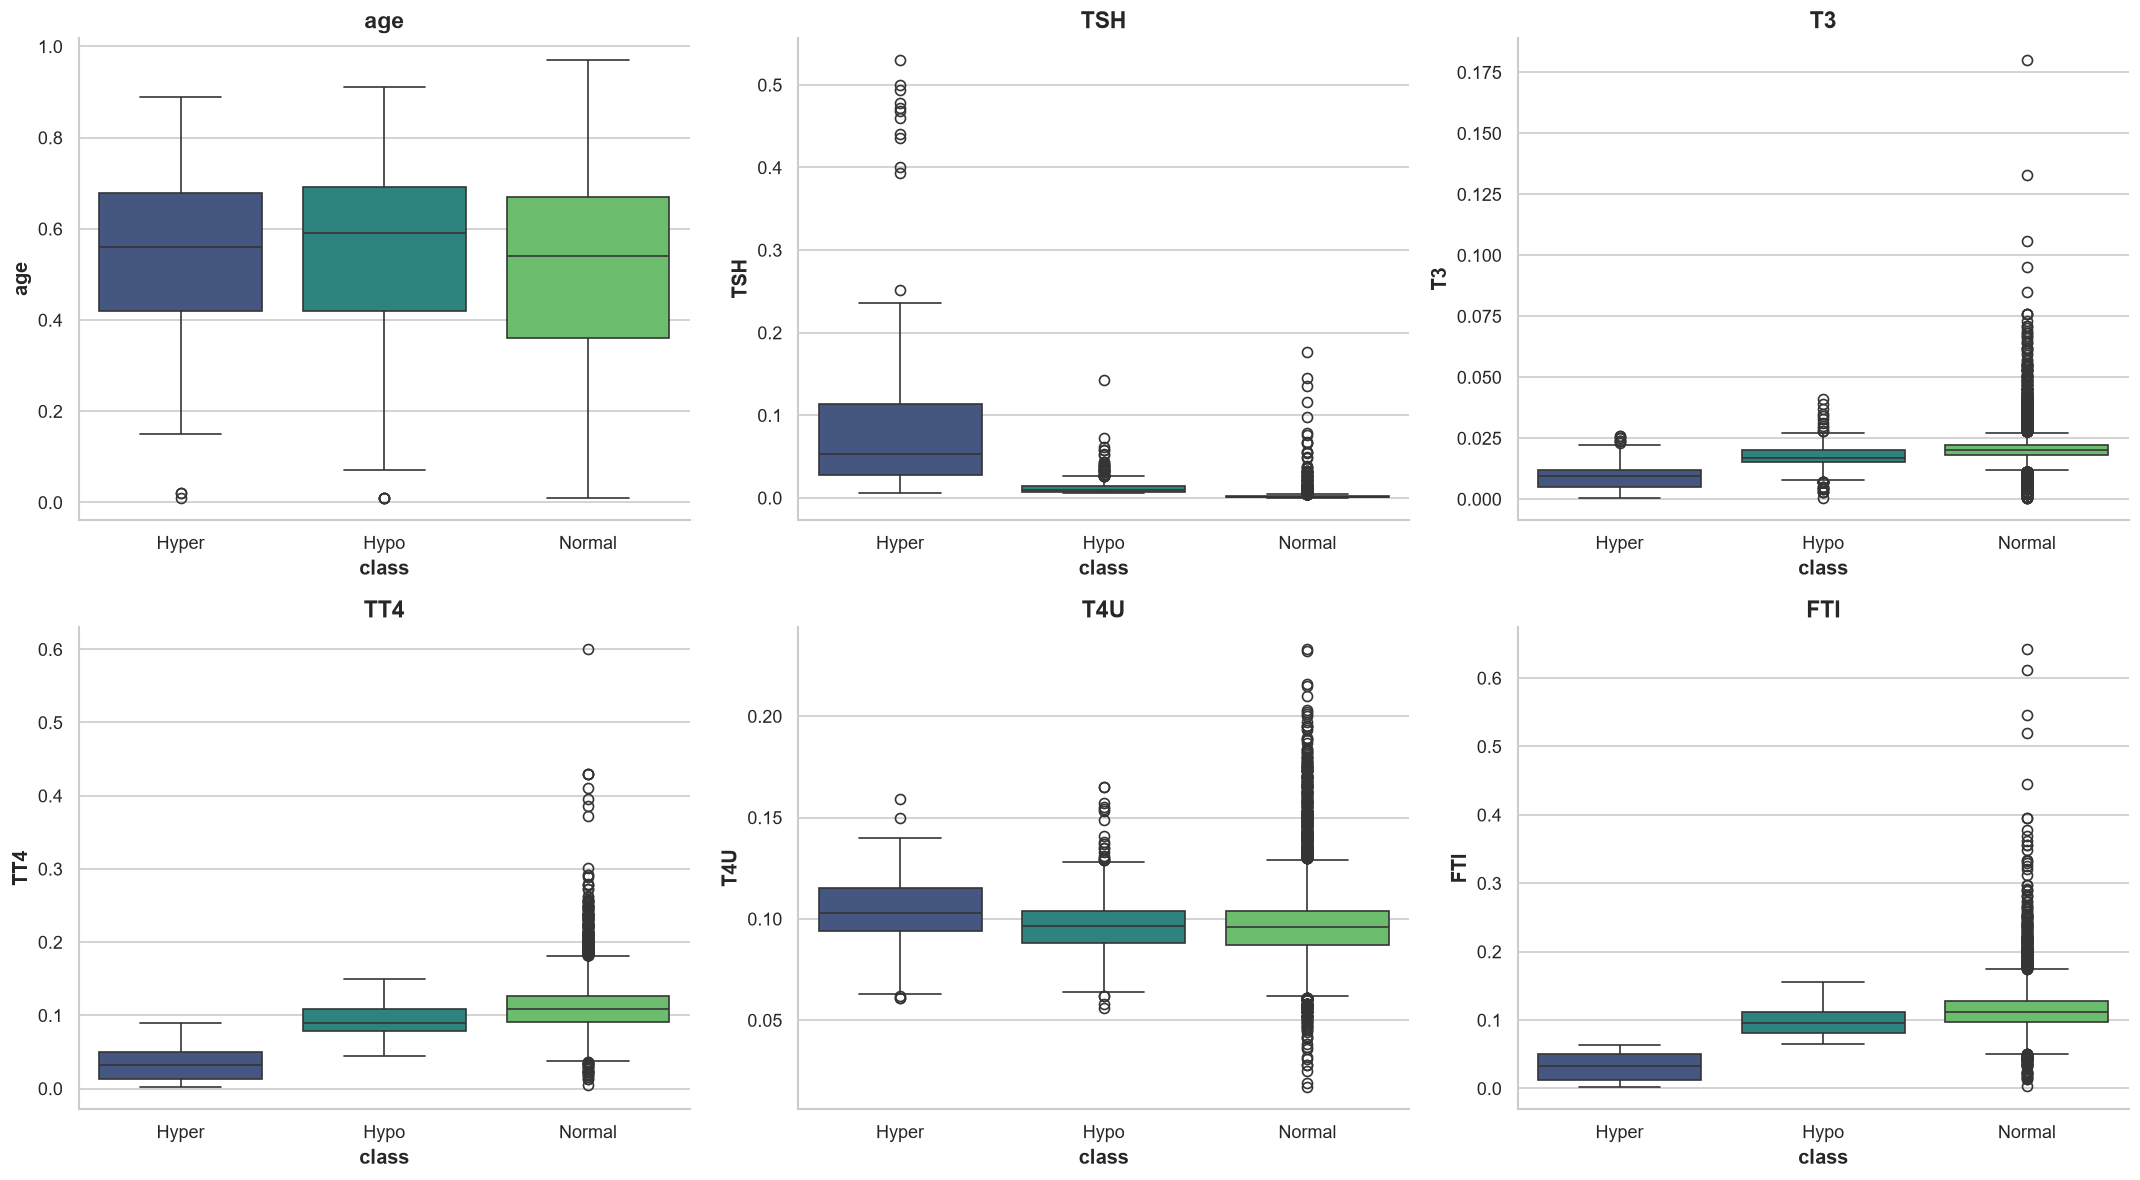

In [33]:
numerical_features = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), numerical_features):

    sns.boxplot(
        data=df,
        x="class",
        y=feature,
        palette="viridis",
        ax=ax
    )

    ax.set_xticklabels([
        "Hyper",
        "Hypo",
        "Normal"
    ])

    ax.set_title(feature)

plt.tight_layout()
plt.show()

The boxplots reveal notable differences in the distributions of the numerical variables across the three thyroid diagnosis classes, suggesting that several laboratory measurements are strongly associated with thyroid status. Age exhibits a similar distribution across all classes, indicating that it may have limited discriminatory power. In contrast, TSH shows substantial variation, with Hyperthyroid patients generally exhibiting higher and more variable values than the other groups. The thyroid hormone measurements (T3, TT4, and FTI) display clear separation between the diagnosis classes, with Hyperthyroid patients consistently having the lowest median values, Hypothyroid patients intermediate values, and Normal patients the highest median values. The distribution of T4U is comparatively similar across the three classes, suggesting weaker discriminative ability. While several laboratory variables contain numerous outliers, particularly within the Normal class, the observed differences in medians and interquartile ranges indicate that these features are likely to be informative predictors for thyroid disease classification. These observations will be statistically validated using the Kruskal–Wallis test in the subsequent analysis.

#### Statistical Testing: Kruskal-Wallis Test

Because the numerical variables are not normally distributed, the Kruskal–Wallis test is more appropriate than ANOVA.

In [34]:
kruskal_results = []

for feature in numerical_features:

    stat, p = stats.kruskal(
        df[df["class"] == 1][feature],
        df[df["class"] == 2][feature],
        df[df["class"] == 3][feature]
    )

    kruskal_results.append({
        "Feature": feature,
        "Statistic": stat,
        "p-value": p
    })

kruskal_results = pd.DataFrame(kruskal_results)

kruskal_results

,Feature,Statistic,p-value
0,age,14.8677,0.0006
1,TSH,1420.0645,0.0000
2,T3,408.0719,0.0000
3,TT4,591.7666,0.0000
4,T4U,28.2463,0.0000
5,FTI,638.3953,0.0000


The Kruskal–Wallis test indicates that all six numerical variables differ significantly across the three thyroid diagnosis classes (p < 0.001). While age shows a statistically significant difference (H = 14.87, p = 0.0006), its relatively small test statistic suggests that the magnitude of the difference is modest compared to the laboratory measurements. Among the laboratory variables, TSH exhibits the largest test statistic (H = 1420.06), indicating the strongest differences between the diagnosis groups. FTI (H = 638.40), TT4 (H = 591.77), and T3 (H = 408.07) also demonstrate substantial between-class differences, while T4U (H = 28.25) shows comparatively weaker, though still statistically significant, variation. These findings support the observations from the boxplots and suggest that the laboratory measurements, particularly TSH, FTI, TT4, and T3, are likely to be the most informative numerical predictors for multiclass thyroid disease classification.

#### 3.4.2 Binary Variables vs Target

We investigate whether the binary clinical indicators are associated with thyroid diagnosis.

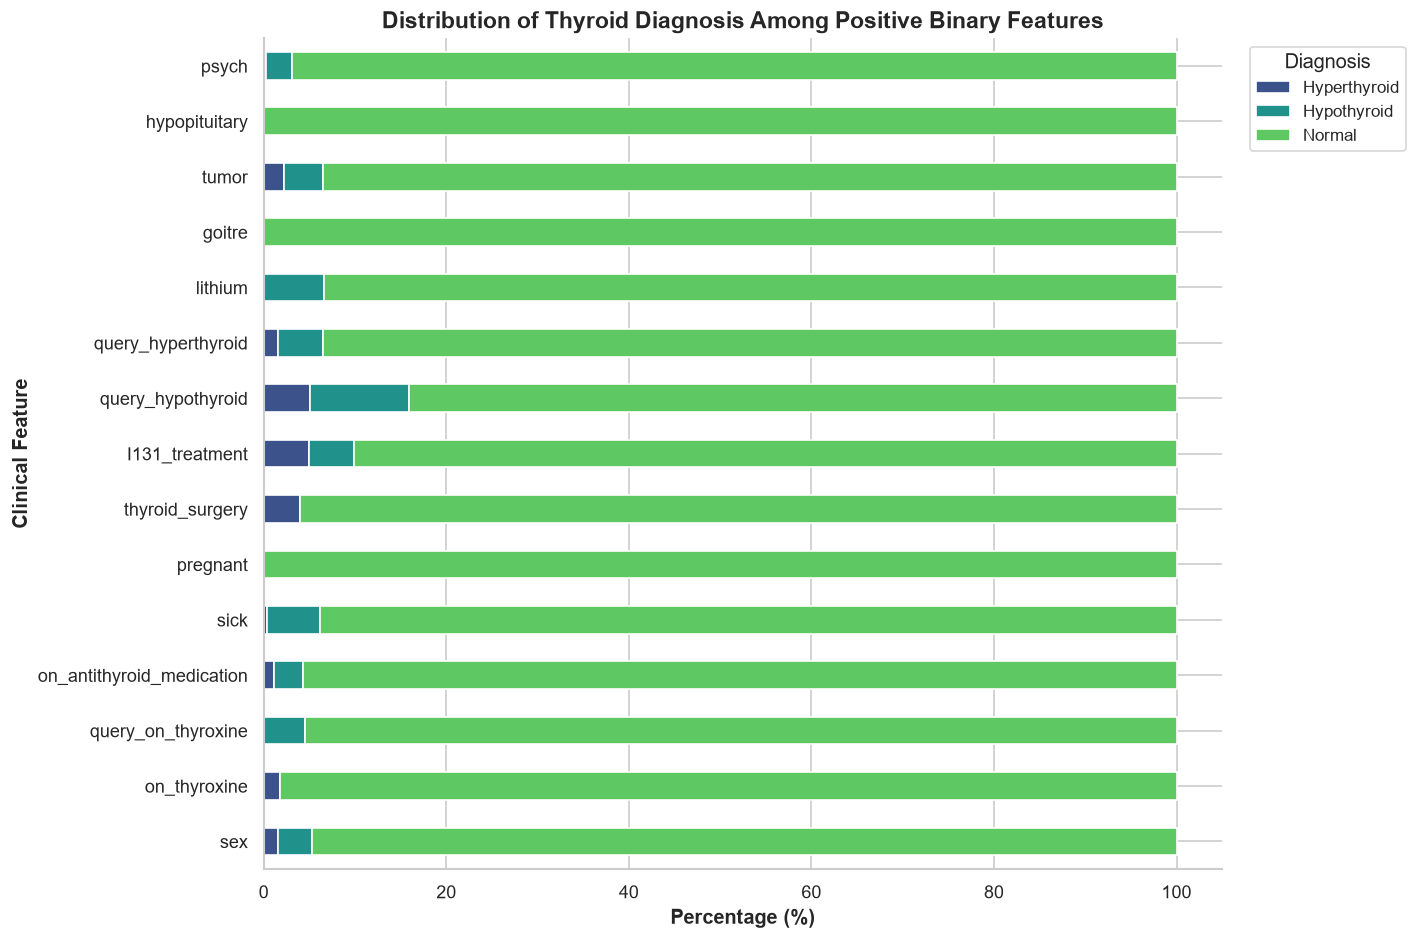

In [41]:
# Calculate percentage distribution for positive (Yes = 1) cases
plot_data = []

for feature in binary_features:
    temp = (
        df[df[feature] == 1]["class"]
        .value_counts(normalize=True)
        .reindex([1, 2, 3], fill_value=0) * 100
    )

    plot_data.append(temp)

plot_df = pd.DataFrame(
    plot_data,
    index=binary_features
)

plot_df.columns = ["Hyperthyroid", "Hypothyroid", "Normal"]

# Horizontal stacked bar chart
ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8),
    color=sns.color_palette("viridis", 3)
)

plt.title(
    "Distribution of Thyroid Diagnosis Among Positive Binary Features"
)
plt.xlabel("Percentage (%)")
plt.ylabel("Clinical Feature")

plt.legend(
    title="Diagnosis",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The distribution of thyroid diagnoses varies across the binary clinical features, indicating that several of these variables are associated with thyroid status. Although the Normal class remains the dominant diagnosis across most positive clinical features, some variables exhibit noticeably higher proportions of Hyperthyroid or Hypothyroid cases. In particular, query_hypothyroid shows the largest proportion of Hypothyroid patients among the positive observations, while features such as tumor, I131_treatment, thyroid_surgery, and on_thyroxine display relatively higher proportions of Hyperthyroid patients compared with the remaining binary variables. Conversely, features such as pregnant, goitre, and hypopituitary are almost exclusively associated with the Normal class, largely reflecting their low prevalence within the dataset. Overall, these patterns suggest that some clinical history and treatment-related variables may provide useful discriminatory information for thyroid disease classification. The strength and statistical significance of these associations will be formally evaluated using the Chi-square test.

#### Chi-Square Test

In [35]:
chi_results = []

for feature in binary_features:

    table = pd.crosstab(df[feature], df["class"])

    chi2, p, dof, expected = chi2_contingency(table)

    chi_results.append({
        "Feature": feature,
        "Chi-square": chi2,
        "p-value": p
    })

chi_results = pd.DataFrame(chi_results)

chi_results.sort_values("p-value")

,Feature,Chi-square,p-value
1,on_thyroxine,60.0901,0.0000
8,query_hypothyroid,52.8797,0.0000
0,sex,21.6824,0.0000
14,psych,11.0276,0.0040
6,thyroid_surgery,6.5846,0.0372
5,pregnant,6.3169,0.0425
4,sick,5.0139,0.0815
11,goitre,4.7654,0.0923
7,I131_treatment,3.8461,0.1462
2,query_on_thyroxine,2.7837,0.2486


The Chi-square test reveals that only a subset of the binary clinical features is significantly associated with thyroid diagnosis. Specifically, on_thyroxine (χ² = 60.09, p < 0.001) and query_hypothyroid (χ² = 52.88, p < 0.001) exhibit the strongest associations with the target variable, suggesting that treatment history and clinical suspicion of hypothyroidism are important indicators of thyroid status. The variables sex (χ² = 21.68, p < 0.001) and psych (χ² = 11.03, p = 0.004) also show statistically significant associations, while thyroid_surgery (χ² = 6.58, p = 0.037) and pregnant (χ² = 6.32, p = 0.043) demonstrate weaker but still significant relationships. In contrast, the remaining binary features, including sick, goitre, I131_treatment, query_on_thyroxine, lithium, on_antithyroid_medication, query_hyperthyroid, tumor, and hypopituitary, do not show statistically significant associations with thyroid diagnosis (p > 0.05). Overall, these findings suggest that only a limited number of binary clinical and treatment variables contribute meaningful discriminatory information, whereas the laboratory measurements identified in the previous analysis are likely to play a more prominent role in thyroid disease classification.

### 3.5 Multivariate Analysis

Multivariate analysis examines the relationships among multiple predictor variables simultaneously to identify underlying patterns, feature interactions, and potential multicollinearity. Understanding these relationships is important for assessing feature redundancy, improving model interpretability, and determining whether the predictors collectively provide sufficient information for accurate thyroid disease classification.

#### 3.5.1 Feature Correlation Analysis

Feature correlation analysis examines the strength and direction of linear relationships among the predictor variables. Identifying highly correlated features helps detect potential multicollinearity, while weakly correlated features are more likely to provide complementary information. This analysis provides an overview of how the demographic, clinical, and laboratory variables relate to one another before model development.

Correlation Matrix

In [44]:
# Correlation matrix of all predictor variables
predictors = df.drop(columns="class")

corr_matrix = predictors.corr()

corr_matrix.round(2)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI
age,1.0000,-0.0000,0.0100,-0.0100,-0.0500,0.0800,-0.1100,-0.0200,0.0600,0.0500,-0.0300,-0.0400,-0.0600,-0.0500,-0.0200,-0.1000,-0.0200,-0.2100,-0.0600,-0.1600,0.0300
sex,-0.0000,1.0000,-0.1000,0.0500,-0.0300,0.0100,-0.0700,-0.0400,-0.0200,-0.0700,-0.0700,0.0300,-0.0000,-0.0700,0.0200,0.1100,-0.0400,-0.0500,-0.1500,-0.2200,-0.0300
on_thyroxine,0.0100,-0.1000,1.0000,-0.0000,-0.0000,-0.0500,-0.0000,0.0200,0.0700,0.1100,-0.0200,-0.0100,0.0000,-0.0200,-0.0000,-0.0600,0.0100,-0.0100,0.2000,0.0400,0.1800
query_on_thyroxine,-0.0100,0.0500,-0.0000,1.0000,-0.0100,-0.0000,0.0300,-0.0100,-0.0200,-0.0200,-0.0300,-0.0100,0.0000,-0.0100,0.0900,-0.0300,-0.0100,-0.0100,-0.0100,-0.0200,0.0100
on_antithyroid_medication,-0.0500,-0.0300,-0.0000,-0.0100,1.0000,-0.0200,0.0400,-0.0100,0.0100,-0.0300,0.1000,-0.0100,-0.0100,-0.0200,-0.0000,-0.0300,-0.0100,0.1000,0.0200,0.0500,-0.0100
sick,0.0800,0.0100,-0.0500,-0.0000,-0.0200,1.0000,-0.0200,-0.0100,-0.0300,0.0100,-0.0200,-0.0100,-0.0200,-0.0000,-0.0000,-0.0300,-0.0200,-0.0600,-0.0300,-0.0200,-0.0300
pregnant,-0.1100,-0.0700,-0.0000,0.0300,0.0400,-0.0200,1.0000,-0.0100,-0.0100,-0.0200,0.0900,-0.0100,0.0400,0.1000,-0.0000,-0.0100,-0.0200,0.1300,0.1300,0.2800,-0.0200
thyroid_surgery,-0.0200,-0.0400,0.0200,-0.0100,-0.0100,-0.0100,-0.0100,1.0000,0.0000,-0.0000,0.0100,-0.0100,-0.0100,0.0000,-0.0000,-0.0300,0.0200,-0.0200,-0.0200,0.0100,-0.0200
I131_treatment,0.0600,-0.0200,0.0700,-0.0200,0.0100,-0.0300,-0.0100,0.0000,1.0000,0.0500,0.0500,-0.0100,-0.0100,-0.0200,-0.0000,-0.0300,0.0100,0.0100,-0.0100,0.0200,-0.0200
query_hypothyroid,0.0500,-0.0700,0.1100,-0.0200,-0.0300,0.0100,-0.0200,-0.0000,0.0500,1.0000,0.0200,-0.0100,-0.0100,-0.0300,-0.0000,-0.0300,0.0400,-0.0600,-0.0200,0.0100,-0.0200


Correlation Heatmap

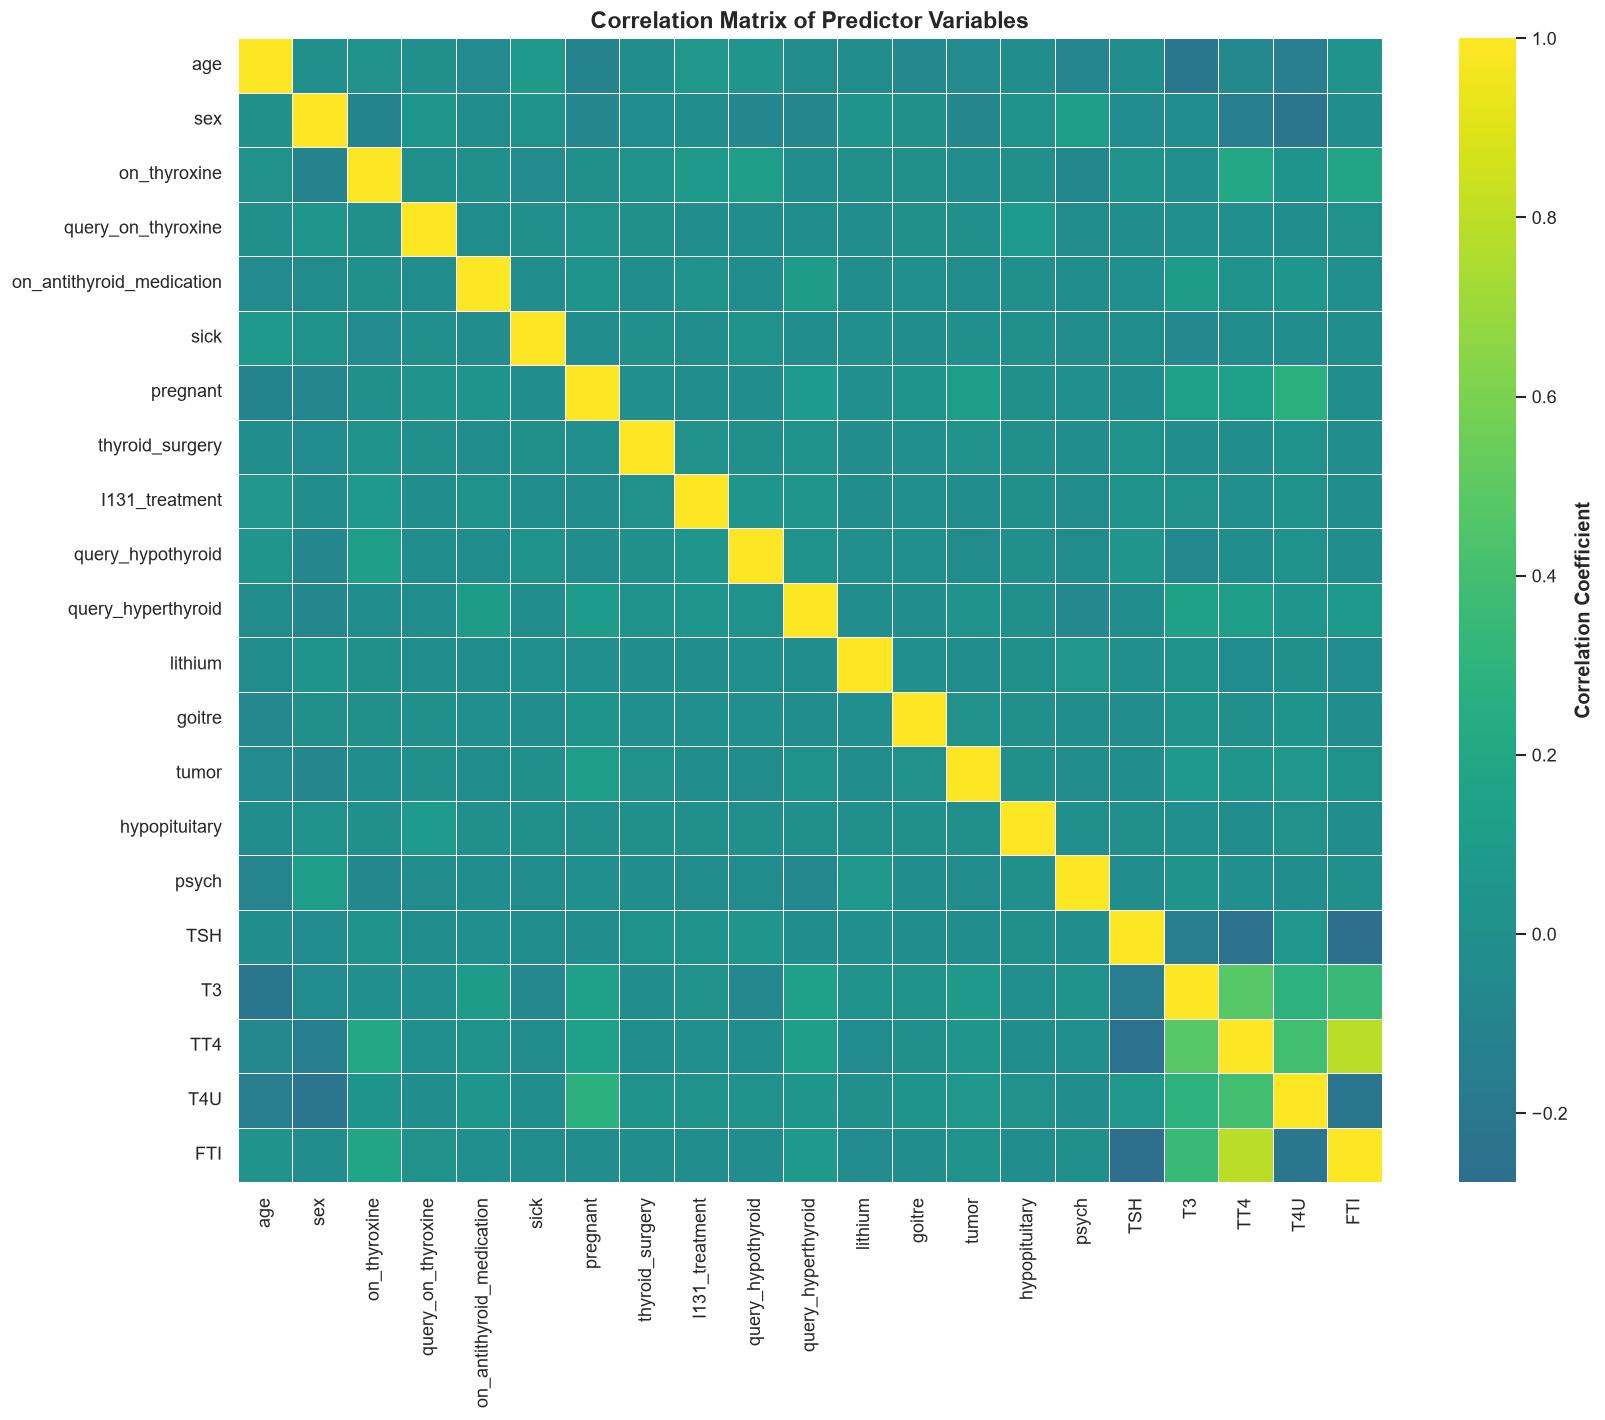

In [45]:
plt.figure(figsize=(15, 12))

sns.heatmap(
    corr_matrix,
    cmap="viridis",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Matrix of Predictor Variables")

plt.tight_layout()
plt.show()

Strongest Correlated Feature Pairs

In [46]:
# Extract strongest correlations
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)

corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

corr_pairs.head(10)

,Feature 1,Feature 2,Correlation
0,TT4,FTI,0.7875
1,T3,TT4,0.4811
2,TT4,T4U,0.3940
3,T3,FTI,0.3497
4,T3,T4U,0.2891
5,pregnant,T4U,0.2773
6,TSH,FTI,0.2771
7,TSH,TT4,0.2569
8,sex,T4U,0.2209
9,age,T3,0.2089


The correlation heatmap indicates that most predictor variables exhibit weak linear relationships, suggesting that the dataset contains limited redundancy and that the features are likely to provide complementary information for model development. The strongest positive correlation is observed between TT4 and FTI (r = 0.79), indicating that these laboratory measurements capture closely related aspects of thyroid function. Moderate positive correlations are also identified between T3 and TT4 (r = 0.48), TT4 and T4U (r = 0.39), T3 and FTI (r = 0.35), and T3 and T4U (r = 0.29), reflecting expected relationships among thyroid hormone measurements. Outside the laboratory variables, relatively weak associations are observed between pregnant and T4U (r = 0.28), sex and T4U (r = 0.22), and age and T3 (|r| = 0.21), while the remaining demographic and clinical variables show little correlation with one another. Overall, no pair of predictors exhibits an exceptionally high correlation (|r| ≥ 0.90), indicating that severe multicollinearity is unlikely to be a concern. Consequently, all predictor variables will be retained for model development, allowing the learning algorithms to determine their relative predictive importance.

### 3.6 Key Exploratory Data Analysis Findings

The exploratory data analysis yielded the following key insights:

- The dataset contains 7,200 patient records with no missing values, 71 duplicate records, and a combination of demographic, clinical, treatment, and laboratory variables suitable for multiclass classification.

- The target variable is highly imbalanced, with the Normal class accounting for 92.58% of all observations, while Hypothyroidism and Hyperthyroidism represent 5.11% and 2.31%, respectively. This class imbalance will be addressed during model development using appropriate resampling techniques and evaluation metrics.

- The numerical laboratory variables exhibit varying degrees of positive skewness and contain several clinically plausible outliers, which will be retained as they may represent genuine patient conditions rather than data quality issues.

- Statistical analysis using the Kruskal–Wallis test confirms that all numerical variables differ significantly across the three thyroid diagnosis classes (p < 0.05), with TSH, FTI, TT4, and T3 demonstrating the strongest discriminatory potential.

- Among the binary variables, only a subset, including on_thyroxine, query_hypothyroid, sex, psych, thyroid_surgery, and pregnant, shows statistically significant associations with thyroid diagnosis based on the Chi-square test.

- Correlation analysis indicates generally weak to moderate relationships among the predictor variables, with the strongest correlation observed between TT4 and FTI (r = 0.79). No evidence of severe multicollinearity was identified, suggesting that all predictor variables can be retained for model development.

- Overall, the exploratory analysis indicates that the dataset possesses meaningful predictive patterns for thyroid disease classification, while also highlighting class imbalance as the primary challenge that must be addressed during the modeling phase.

## 4. Data Preprocessing

Data preprocessing prepares the dataset for machine learning by addressing data quality issues and transforming the data into a format suitable for model development. Guided by the findings from the exploratory data analysis, this stage removes duplicate observations, partitions the dataset into training and testing sets, and prepares alternative training datasets to evaluate different class imbalance handling strategies. Feature scaling is then applied where required by specific machine learning algorithms to ensure optimal model performance.

### 4.1 Duplicate Removal

Duplicate observations can introduce bias during model training by overrepresenting certain patterns within the dataset. Based on the data quality assessment, duplicate records are identified and removed to ensure that each patient contributes only one observation to the learning process.

In [47]:
# Remove duplicate observations
df = df.drop_duplicates()

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (7129, 22)


In [49]:
# Verification
print(f"Remaining duplicate records: {df.duplicated().sum()}")

Remaining duplicate records: 0


A total of 71 duplicate observations were identified and removed from the dataset. Eliminating duplicate records reduces the risk of overrepresenting identical patient profiles during model training and improves the reliability of model evaluation. The cleaned dataset will be used for all subsequent preprocessing and modeling steps.

### 4.2 Feature and Target Separation

The predictor variables and target variable are separated to prepare the dataset for machine learning. The predictor matrix contains the demographic, clinical, treatment, and laboratory variables, while the target variable represents the multiclass thyroid diagnosis.

In [50]:
# Separate predictors and target

X = df.drop(columns="class")
y = df["class"]

print(f"Predictor matrix shape : {X.shape}")
print(f"Target vector shape    : {y.shape}")

Predictor matrix shape : (7129, 21)
Target vector shape    : (7129,)


In [51]:
#Verify Target Distribution

y.value_counts().sort_index()

class
1     166
2     368
3    6595
Name: count, dtype: int64

The dataset contains 21 predictor variables and a multiclass target variable with three thyroid diagnosis classes. Separating the predictors from the target prepares the data for partitioning into training and testing sets while preserving the original class distribution.

### 4.3 Train-Test Split

The cleaned dataset is partitioned into training and testing sets to enable unbiased evaluation of model performance on unseen data. An 80:20 split is used, with 80% of the observations allocated for model training and 20% reserved for final evaluation. Given the substantial class imbalance identified during EDA, stratified sampling is applied to preserve the relative distribution of the three thyroid diagnosis classes in both subsets.

In [52]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training features : {X_train.shape}")
print(f"Testing features  : {X_test.shape}")
print(f"Training target   : {y_train.shape}")
print(f"Testing target    : {y_test.shape}")

Training features : (5703, 21)
Testing features  : (1426, 21)
Training target   : (5703,)
Testing target    : (1426,)


Verification of Stratification

In [53]:
# Compare class distributions
split_distribution = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Training Set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Testing Set (%)": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_distribution.index = [
    "Hyperthyroid",
    "Hypothyroid",
    "Normal"
]

split_distribution

,Full Dataset (%),Training Set (%),Testing Set (%)
Hyperthyroid,2.3300,2.3300,2.3100
Hypothyroid,5.1600,5.1600,5.1900
Normal,92.5100,92.5100,92.5000


The stratified 80:20 train-test split successfully preserved the original class distribution. Hyperthyroid cases account for approximately 2.33% of the full and training datasets and 2.31% of the test set, while Hypothyroid cases remain close to 5.16% and Normal cases approximately 92.5% across all subsets. This consistency ensures that both the training and testing sets remain representative of the original class imbalance, while the test set can provide an unbiased evaluation of model performance on unseen data.

### 4.4 Class Imbalance Strategy

The exploratory analysis revealed substantial class imbalance, with Normal cases accounting for approximately 92.5% of the dataset, compared with about 5.2% Hypothyroid and 2.3% Hyperthyroid cases. Such imbalance may cause classification models to favour the majority class while performing poorly on the minority disease classes.

Rather than applying a single imbalance correction method by default, three strategies will be evaluated: training on the original imbalanced data, applying class weighting, and using Synthetic Minority Over-sampling Technique (SMOTE). Their effectiveness will be compared during model development using Macro F1-score, Balanced Accuracy, and class-specific performance metrics.

#### 4.4.1 Original Training Data

The original training data are retained without resampling or class weighting to establish baseline model performance. This provides a reference against which the effectiveness of subsequent class imbalance handling strategies can be evaluated.

In [54]:
# Class distribution in the original training set
original_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage (%)": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

original_distribution.index = [
    "Hyperthyroid",
    "Hypothyroid",
    "Normal"
]

original_distribution

,Count,Percentage (%)
Hyperthyroid,133,2.3300
Hypothyroid,294,5.1600
Normal,5276,92.5100


#### 4.4.2 Class Weighting
Class weighting assigns greater importance to observations from underrepresented classes during model training without altering the original training data. Models that support class weighting will be trained using weights that compensate for differences in class frequency. This approach allows the impact of imbalance correction to be evaluated without generating synthetic observations.

In [60]:
# Calculate balanced class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_weight_table = pd.DataFrame({
    "Class": ["Hyperthyroid", "Hypothyroid", "Normal"],
    "Weight": [class_weights[1], class_weights[2], class_weights[3]]
})

class_weight_table

,Class,Weight
0,Hyperthyroid,14.2932
1,Hypothyroid,6.4660
2,Normal,0.3603


#### 4.4.3 SMOTE Oversampling

SMOTE addresses class imbalance by generating synthetic minority-class observations based on neighbouring samples rather than simply duplicating existing records. To prevent information leakage, SMOTE is applied exclusively to the training data, while the test set remains unchanged. The resulting dataset provides a third training condition for evaluating whether synthetic oversampling improves minority-class prediction.

In [62]:
# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(f"Original training shape : {X_train.shape}")
print(f"SMOTE training shape    : {X_train_smote.shape}")

Original training shape : (5703, 21)
SMOTE training shape    : (15828, 21)


Before and After Smote Comparison.

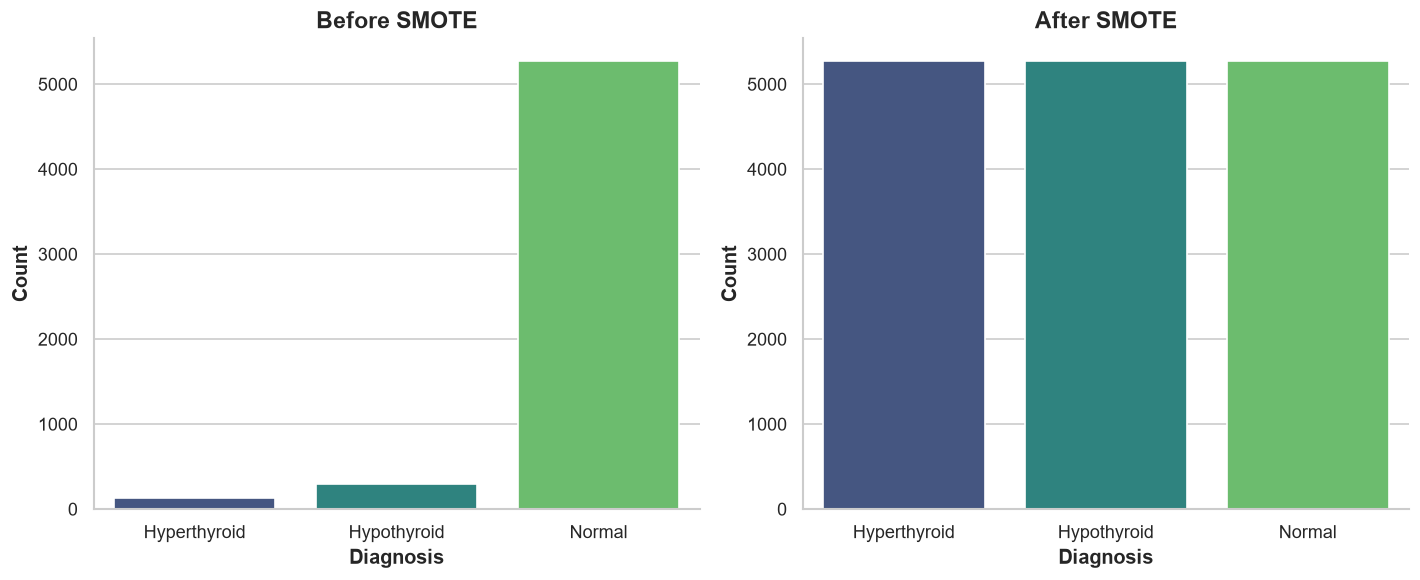

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    x=y_train,
    order=[1, 2, 3],
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(
    ["Hyperthyroid", "Hypothyroid", "Normal"]
)

sns.countplot(
    x=y_train_smote,
    order=[1, 2, 3],
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(
    ["Hyperthyroid", "Hypothyroid", "Normal"]
)

plt.tight_layout()
plt.show()

The original training data exhibit substantial class imbalance, with the Normal class greatly outnumbering both thyroid disease classes. After applying SMOTE, the Hyperthyroid and Hypothyroid classes are synthetically oversampled to match the number of Normal observations, resulting in an evenly balanced training dataset. Importantly, SMOTE is applied only to the training data, leaving the test set unchanged. Whether this improved class balance translates into better minority-class prediction will be evaluated during model development against the original and class-weighted approaches.

### 4.5 Feature Scaling

The predictor variables are measured on different scales, which can disproportionately influence algorithms that rely on distances or optimization procedures. Standardization is therefore applied to scale the features to a common scale with a mean of zero and a standard deviation of one. Scaling is performed using parameters learned exclusively from the training data to prevent information leakage from the test set.

#### 4.6.1 Scaling the Original Training Data

In [65]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training parameters
X_test_scaled = scaler.transform(X_test)

Converting them back to DataFrames to retain the feature names.

In [66]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (5703, 21)
Scaled testing shape : (1426, 21)


#### 4.6.2 Scaling the SMOTE Training Data

In [67]:
X_train_smote_scaled = scaler.transform(X_train_smote)

X_train_smote_scaled = pd.DataFrame(
    X_train_smote_scaled,
    columns=X_train.columns
)

print("Scaled SMOTE training shape:", X_train_smote_scaled.shape)

Scaled SMOTE training shape: (15828, 21)


This keeps the scaling parameters based on the real training observations, rather than allowing synthetic SMOTE observations to influence the mean and standard deviation.

#### 4.6.3 Scaled and Unscaled Data for Model Development

Feature scaling is required only for algorithms whose performance is sensitive to differences in feature magnitude. Therefore, both scaled and unscaled versions of the training data are retained for model development.

Scale-sensitive models, including Logistic Regression, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN), will be trained using the standardized features. Tree-based models will use the original unscaled features because their decision-making process is not affected by differences in feature scale.

The same principle will be applied when evaluating the original, class-weighted, and SMOTE training strategies.

| Model               | Original / Class-Weighted | SMOTE                  | Scaling |
| ------------------- | ------------------------- | ---------------------- | ------- |
| Logistic Regression | `X_train_scaled`          | `X_train_smote_scaled` | Yes     |
| SVM                 | `X_train_scaled`          | `X_train_smote_scaled` | Yes     |
| KNN                 | `X_train_scaled`          | `X_train_smote_scaled` | Yes     |
| Decision Tree       | `X_train`                 | `X_train_smote`        | No      |
| Random Forest       | `X_train`                 | `X_train_smote`        | No      |
| XGBoost             | `X_train`                 | `X_train_smote`        | No      |
| LightGBM            | `X_train`                 | `X_train_smote`        | No      |
| CatBoost            | `X_train`                 | `X_train_smote`        | No      |


The preprocessing stage produced clean and appropriately structured datasets for model development while minimizing the risk of data leakage. Duplicate records were removed, the data were partitioned using a stratified train-test split, and the test set was preserved for final evaluation. Both original and SMOTE-resampled training datasets were prepared, while class weighting will be implemented directly within compatible models. Standardized versions were also created for scale-sensitive algorithms, with unscaled data retained for tree-based models. This framework enables a consistent comparison of the original, class-weighted, and SMOTE strategies during model development.

## 5. Model Development and Evaluation

### 5.1 Modeling Strategy

This section develops and evaluates multiple supervised classification algorithms for predicting Hyperthyroidism, Hypothyroidism, and Normal thyroid function. To determine the effect of class imbalance on predictive performance, models will be evaluated using the original training data, class weighting where supported, and SMOTE-resampled training data.

All models will be evaluated on the same untouched test set to ensure a consistent and unbiased comparison. Model selection will primarily be based on Macro F1-score, with Balanced Accuracy, class-specific Precision, Recall, and F1-scores, and confusion matrices used to provide additional insight into performance across the three diagnosis classes.

### 5.2 Evaluation Metrics

Given the substantial class imbalance, overall Accuracy is insufficient as the primary measure of model performance. Macro F1-score is therefore used as the primary model-selection metric because it calculates the F1-score independently for each diagnosis class and assigns equal importance to all three classes regardless of their frequency.

Balanced Accuracy is used as a complementary metric to assess performance across classes, while class-specific Precision, Recall, and F1-scores are examined to determine how effectively each model identifies Hyperthyroid, Hypothyroid, and Normal patients. Confusion matrices are additionally used to analyse the types and frequency of classification errors.

### 5.3 Baseline Model Development

Baseline classification models are developed to establish initial performance before hyperparameter tuning. Each algorithm is trained using its standard configuration under the applicable imbalance strategies: original training data, class weighting, and SMOTE. Evaluating these strategies separately allows the effect of class imbalance handling to be assessed for each algorithm.

The baseline results will subsequently be compared to identify the strongest model and imbalance-strategy combinations for further optimization.

Model Evaluation Funtion

In [68]:
def evaluate_model(model, X_test, y_test, model_name, strategy):
    # Generate predictions
    y_pred = model.predict(X_test)

    # Calculate overall metrics
    results = {
        "Model": model_name,
        "Strategy": strategy,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, y_pred, average="macro", zero_division=0
        )
    }

    return results, y_pred

In [73]:
model_results = []

#### 5.3.1 Logistic Regression

Logistic Regression provides an interpretable baseline for multiclass classification and estimates class probabilities using linear combinations of the predictor variables. Because the algorithm is sensitive to differences in feature scale, the standardized datasets are used for training and evaluation.

Three variants are evaluated: the original imbalanced training data, class-weighted training, and SMOTE-resampled training.

In [74]:
# Logistic Regression variants
lr_models = {
    "Original": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Class Weighted": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    
    "SMOTE": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# Store predictions for later analysis
lr_predictions = {}

# Train and evaluate each variant
for strategy, model in lr_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote_scaled
        y_fit = y_train_smote
    else:
        X_fit = X_train_scaled
        y_fit = y_train

    # Train model
    model.fit(X_fit, y_fit)

    # Evaluate model
    results, predictions = evaluate_model(
        model,
        X_test_scaled,
        y_test,
        "Logistic Regression",
        strategy
    )

    model_results.append(results)
    lr_predictions[strategy] = predictions

# Compare Logistic Regression variants
lr_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "Logistic Regression"
])

lr_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,Original,0.9495,0.6311,0.8202,0.6311,0.6930
1,Logistic Regression,Class Weighted,0.9649,0.9634,0.7825,0.9634,0.8559
2,Logistic Regression,SMOTE,0.9727,0.9465,0.8115,0.9465,0.8696


The results demonstrate that addressing class imbalance substantially improves Logistic Regression performance. Although the Original model achieves a relatively high Accuracy of 94.95%, its considerably lower Balanced Accuracy (0.6311) and Macro F1-score (0.6930) indicate weaker performance across the minority thyroid classes. Class weighting significantly improves Balanced Accuracy to 0.9634 and Macro F1 to 0.8559, demonstrating much stronger performance across all three classes. SMOTE achieves the highest Accuracy (97.27%) and Macro F1-score (0.8696), making it the strongest Logistic Regression variant based on the primary evaluation criterion. However, the Class-Weighted model records the highest Balanced Accuracy (0.9634), indicating slightly stronger average recall across the three classes. Overall, both imbalance-handling strategies considerably outperform the Original model, with SMOTE providing the best overall balance between precision and recall.

Logistic Regression Confusion Matrices

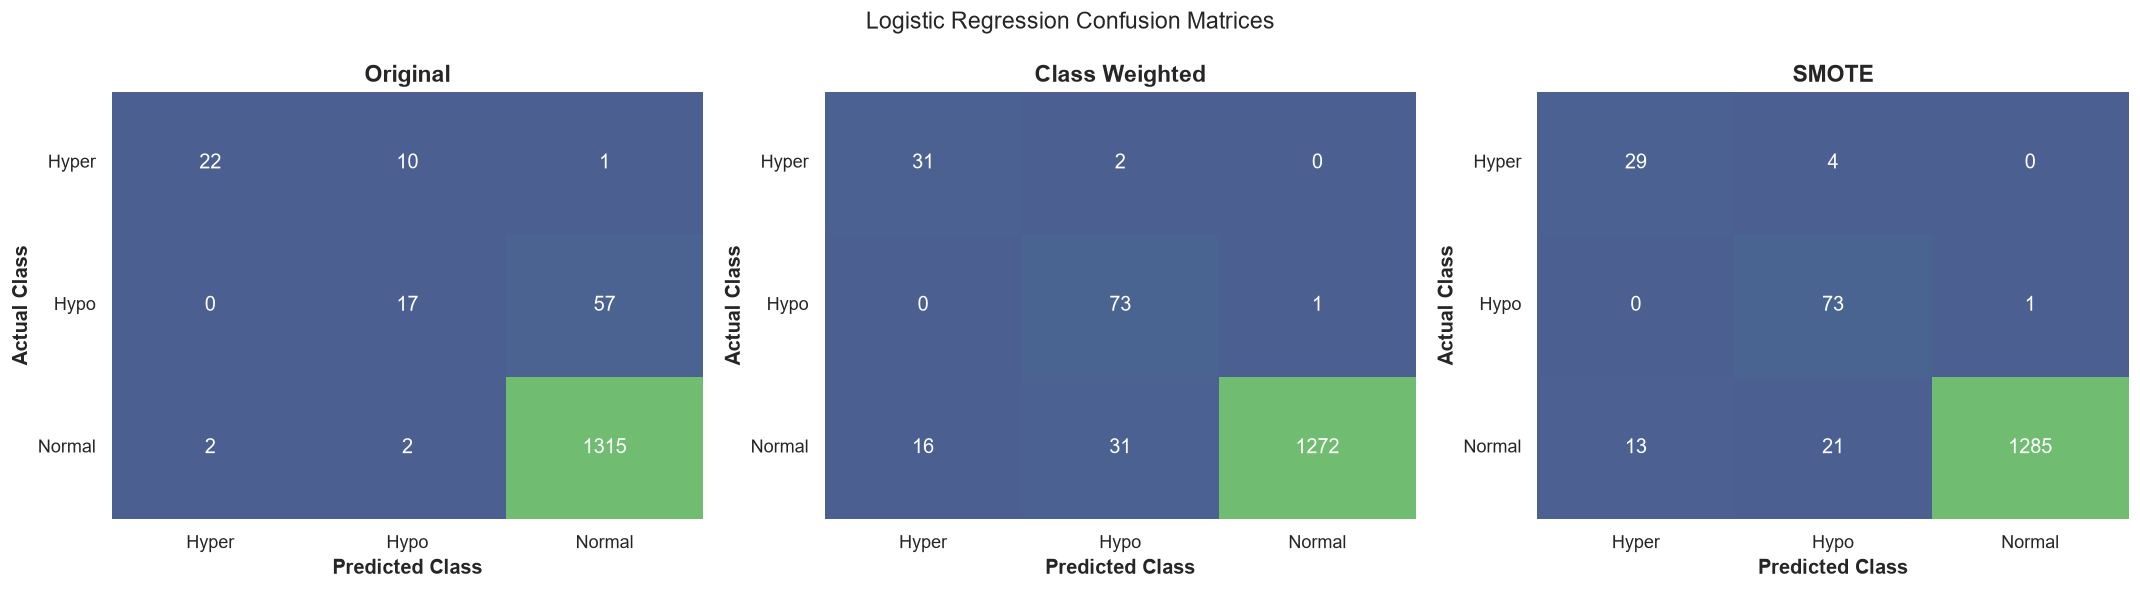

In [82]:

smote_colors = ["#4C5F91", "#358C87", "#70BC70"]

custom_cmap = LinearSegmentedColormap.from_list(
    "blue_teal_green",
    smote_colors
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, lr_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "Logistic Regression Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

The Original model performs well on Normal cases but poorly detects Hypothyroidism, misclassifying 57 cases as Normal. Both imbalance strategies substantially improve minority-class detection. Class weighting achieves slightly better Hyperthyroid detection, while SMOTE reduces false disease predictions among Normal cases. Overall, SMOTE provides the best balance across the three classes.

#### 5.3.2 Decision Tree

Decision Tree is a non-linear classification algorithm that predicts outcomes by recursively partitioning the feature space based on decision rules. Unlike Logistic Regression, it does not require feature scaling. The model is evaluated using the Original, Class-Weighted, and SMOTE training strategies.

In [83]:
# Decision Tree variants
dt_models = {
    "Original": DecisionTreeClassifier(
        random_state=42
    ),

    "Class Weighted": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "SMOTE": DecisionTreeClassifier(
        random_state=42
    )
}

# Store predictions
dt_predictions = {}

# Train and evaluate
for strategy, model in dt_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote
        y_fit = y_train_smote
    else:
        X_fit = X_train
        y_fit = y_train

    model.fit(X_fit, y_fit)

    results, predictions = evaluate_model(
        model,
        X_test,
        y_test,
        "Decision Tree",
        strategy
    )

    model_results.append(results)
    dt_predictions[strategy] = predictions

# Compare Decision Tree variants
dt_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "Decision Tree"
])

dt_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Decision Tree,Original,0.9972,0.9849,0.9906,0.9849,0.9877
1,Decision Tree,Class Weighted,0.9993,0.9899,0.9997,0.9899,0.9947
2,Decision Tree,SMOTE,0.9979,0.9851,0.9950,0.9851,0.9900


All three Decision Tree variants achieve excellent classification performance. The Class-Weighted model performs best, achieving the highest Accuracy (99.93%), Balanced Accuracy (0.9899), and Macro F1-score (0.9947). SMOTE also performs strongly but provides no improvement over class weighting. Overall, class weighting is the most effective imbalance strategy for the Decision Tree model.

Decision Tree Confusion Matrices

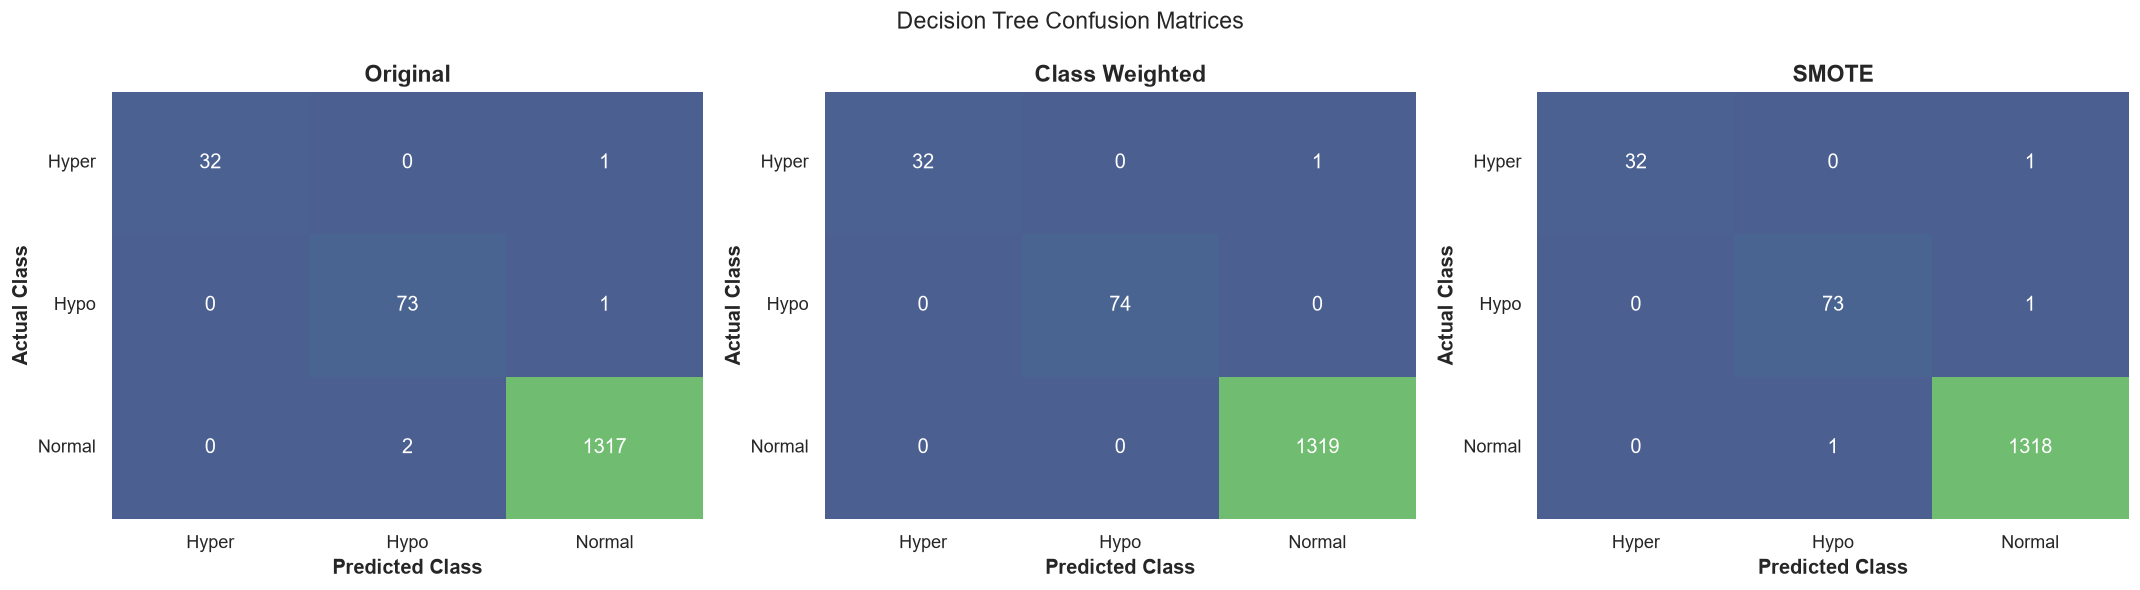

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, dt_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "Decision Tree Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

The Decision Tree performs exceptionally well across all three strategies. The Original and SMOTE models make only four and three misclassifications, respectively. Class weighting provides the strongest performance, correctly classifying all Hypothyroid and Normal cases, with only one Hyperthyroid case misclassified as Normal. This confirms the Class-Weighted Decision Tree as the best-performing variant

#### 5.3.3 Random Forest

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees to improve classification performance and reduce overfitting. As a tree-based method, it does not require feature scaling. The Original, Class-Weighted, and SMOTE strategies are evaluated to determine the effect of class imbalance handling on model performance.

In [85]:
# Random Forest variants
rf_models = {
    "Original": RandomForestClassifier(
        random_state=42
    ),

    "Class Weighted": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "SMOTE": RandomForestClassifier(
        random_state=42
    )
}

# Store predictions
rf_predictions = {}

# Train and evaluate
for strategy, model in rf_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote
        y_fit = y_train_smote
    else:
        X_fit = X_train
        y_fit = y_train

    model.fit(X_fit, y_fit)

    results, predictions = evaluate_model(
        model,
        X_test,
        y_test,
        "Random Forest",
        strategy
    )

    model_results.append(results)
    rf_predictions[strategy] = predictions

# Compare Random Forest variants
rf_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "Random Forest"
])

rf_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,Original,0.9979,0.9894,0.9811,0.9894,0.9852
1,Random Forest,Class Weighted,0.9965,0.9987,0.9731,0.9987,0.9856
2,Random Forest,SMOTE,0.9972,0.9990,0.9772,0.9990,0.9879


All three Random Forest variants demonstrate excellent performance. The Original model achieves a Macro F1-score of 0.9852, which improves slightly with Class Weighting (0.9856) and SMOTE (0.9879). SMOTE produces the highest Macro F1-score and Balanced Accuracy (0.9990), making it the strongest Random Forest variant. However, the small differences indicate that Random Forest is already highly robust to the class imbalance in this dataset.

Random Forest Confusion Matrices

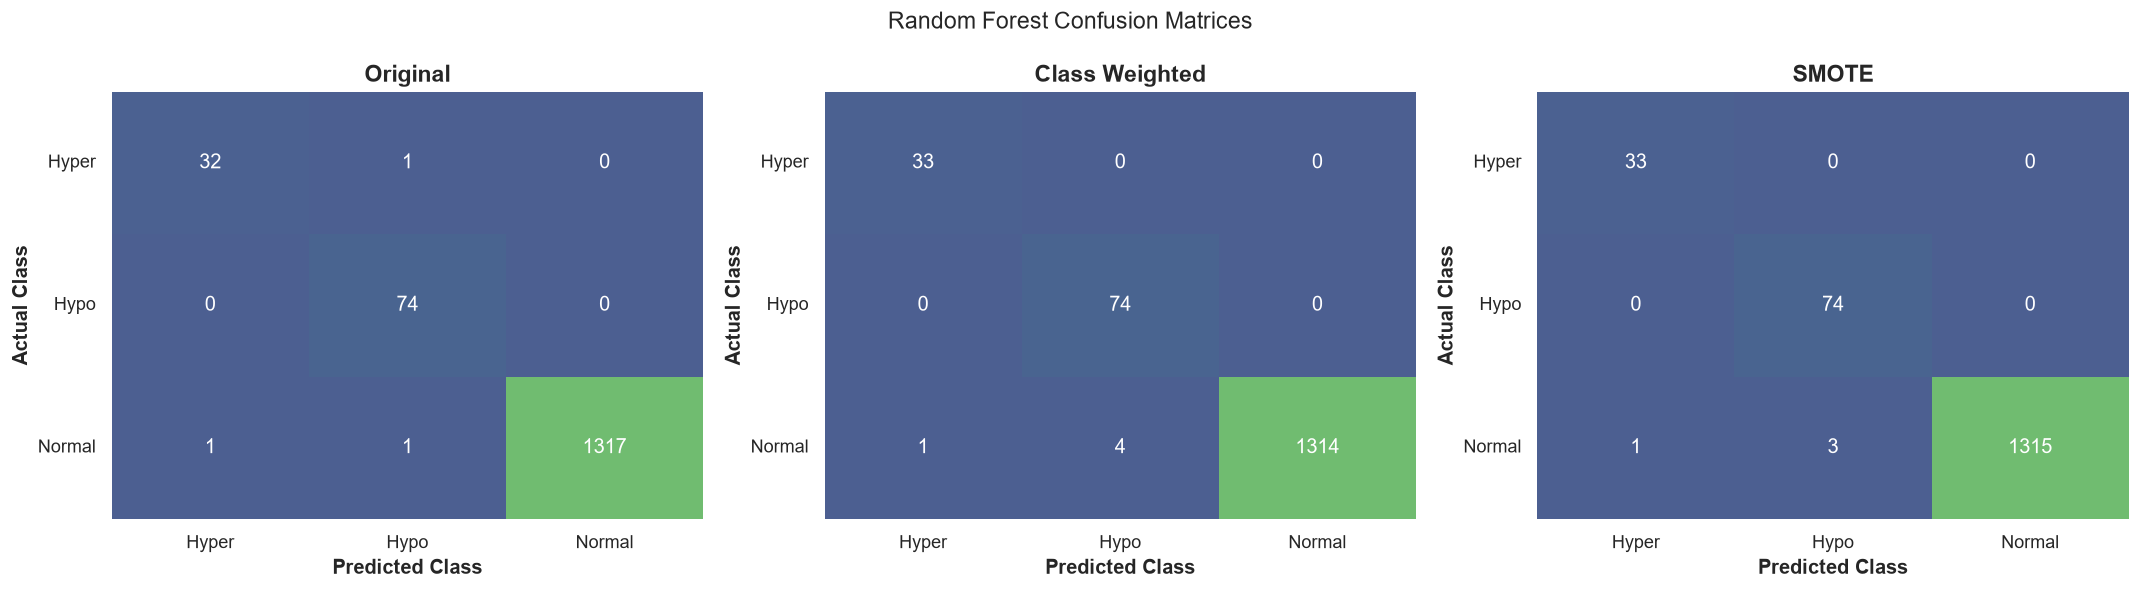

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, rf_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "Random Forest Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

Random Forest performs exceptionally well across all strategies. Both Class Weighting and SMOTE correctly classify all Hyperthyroid and Hypothyroid cases, while producing only a few false-positive disease predictions among Normal cases. SMOTE achieves the highest Macro F1-score (0.9879), making it the strongest Random Forest variant overall.

#### 5.3.4 Support Vector Machine (SVM)

Support Vector Machine is a classification algorithm that identifies optimal decision boundaries between classes by maximizing the separation between observations. Since SVM is sensitive to differences in feature scale, standardized predictor variables are used. The Original, Class-Weighted, and SMOTE strategies are evaluated to assess the effect of class imbalance handling.

In [87]:
# SVM variants
svm_models = {
    "Original": SVC(
        random_state=42
    ),

    "Class Weighted": SVC(
        class_weight="balanced",
        random_state=42
    ),

    "SMOTE": SVC(
        random_state=42
    )
}

# Store predictions
svm_predictions = {}

# Train and evaluate
for strategy, model in svm_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote_scaled
        y_fit = y_train_smote
    else:
        X_fit = X_train_scaled
        y_fit = y_train

    model.fit(X_fit, y_fit)

    results, predictions = evaluate_model(
        model,
        X_test_scaled,
        y_test,
        "SVM",
        strategy
    )

    model_results.append(results)
    svm_predictions[strategy] = predictions

# Compare SVM variants
svm_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "SVM"
])

svm_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,SVM,Original,0.9530,0.6395,0.8859,0.6395,0.7198
1,SVM,Class Weighted,0.9355,0.9092,0.7004,0.9092,0.7740
2,SVM,SMOTE,0.9663,0.9456,0.8217,0.9456,0.8732


VM performance improves considerably when class imbalance is addressed. The Original model records a Macro F1-score of 0.7198, while Class Weighting improves it to 0.7740. SMOTE achieves the strongest performance, with the highest Accuracy (96.63%), Balanced Accuracy (0.9456), and Macro F1-score (0.8732). Overall, SMOTE is the most effective imbalance strategy for SVM.

SVM Confusion Matrices

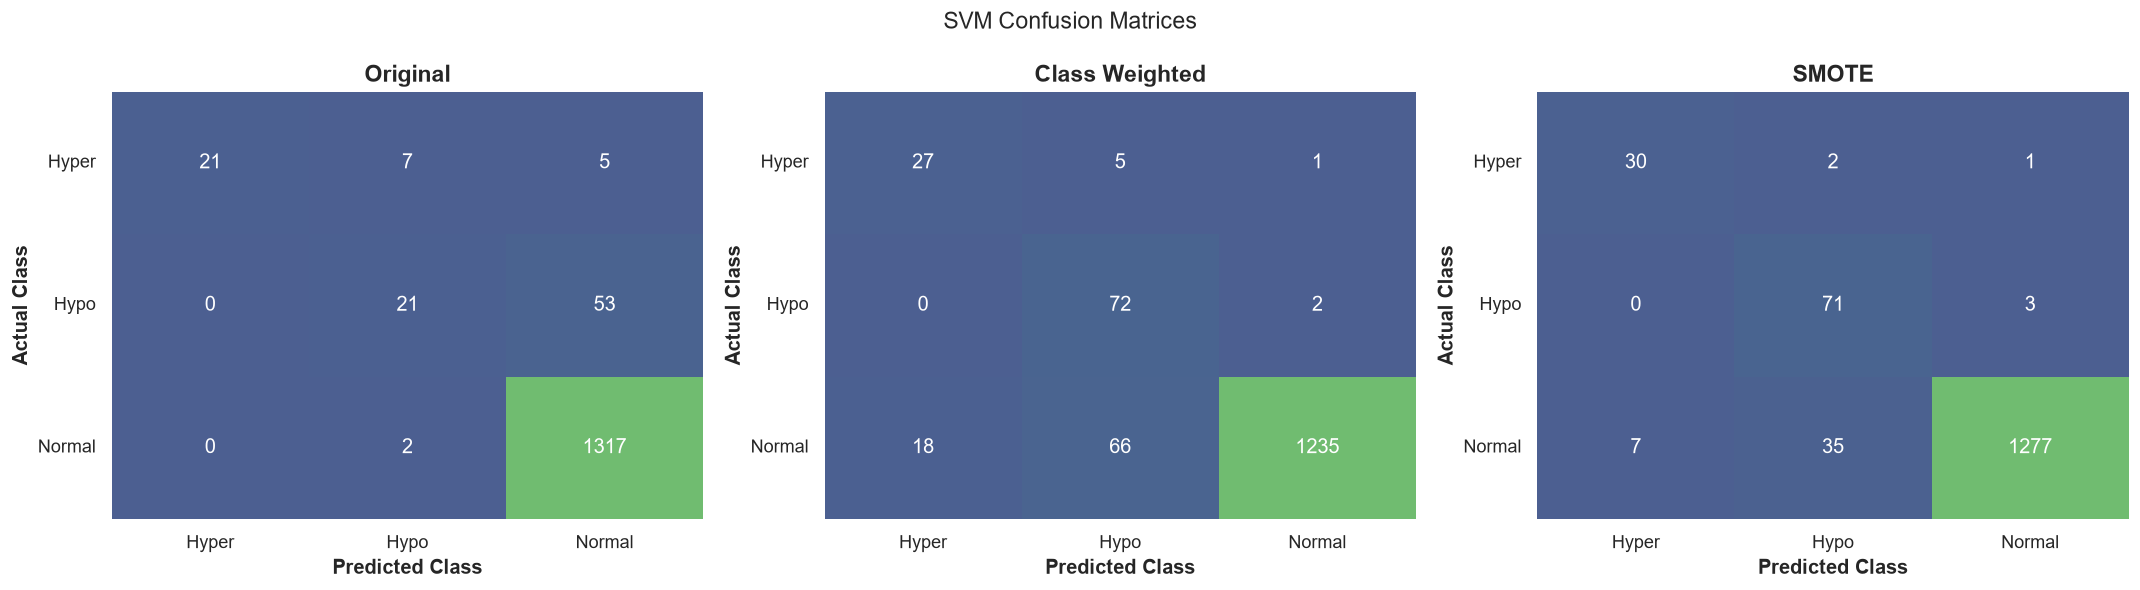

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, svm_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "SVM Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

The Original SVM struggles with minority-class detection, particularly Hypothyroidism, with 53 cases misclassified as Normal. Class weighting substantially improves disease detection but increases misclassification of Normal cases. SMOTE provides the best balance, improving both minority-class detection and Normal-class classification, consistent with its highest Macro F1-score of 0.8732.

#### 5.3.5 K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based classification algorithm that assigns observations to classes based on the classes of their nearest neighbouring observations. Since distance calculations are sensitive to differences in feature scale, standardized features are used. KNN does not directly support class weighting; therefore, only the Original and SMOTE strategies are evaluated.

In [90]:
# KNN variants
knn_models = {
    "Original": KNeighborsClassifier(),
    "SMOTE": KNeighborsClassifier()
}

# Store predictions
knn_predictions = {}

# Train and evaluate
for strategy, model in knn_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote_scaled
        y_fit = y_train_smote
    else:
        X_fit = X_train_scaled
        y_fit = y_train

    # Train model
    model.fit(X_fit, y_fit)

    # Evaluate model
    results, predictions = evaluate_model(
        model,
        X_test_scaled,
        y_test,
        "KNN",
        strategy
    )

    model_results.append(results)
    knn_predictions[strategy] = predictions

# Compare KNN variants
knn_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "KNN"
])

knn_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,KNN,Original,0.9502,0.6370,0.8650,0.6370,0.7069
1,KNN,SMOTE,0.8864,0.8035,0.6707,0.8035,0.7091


KNN shows limited improvement with SMOTE. While SMOTE increases Balanced Accuracy from 0.6370 to 0.8035, indicating better minority-class detection, overall Accuracy decreases from 95.02% to 88.64%. Macro F1 improves only slightly from 0.7069 to 0.7091. Overall, SMOTE improves class balance but provides minimal improvement in KNN's overall classification performance.

KNN Confusion Matrices

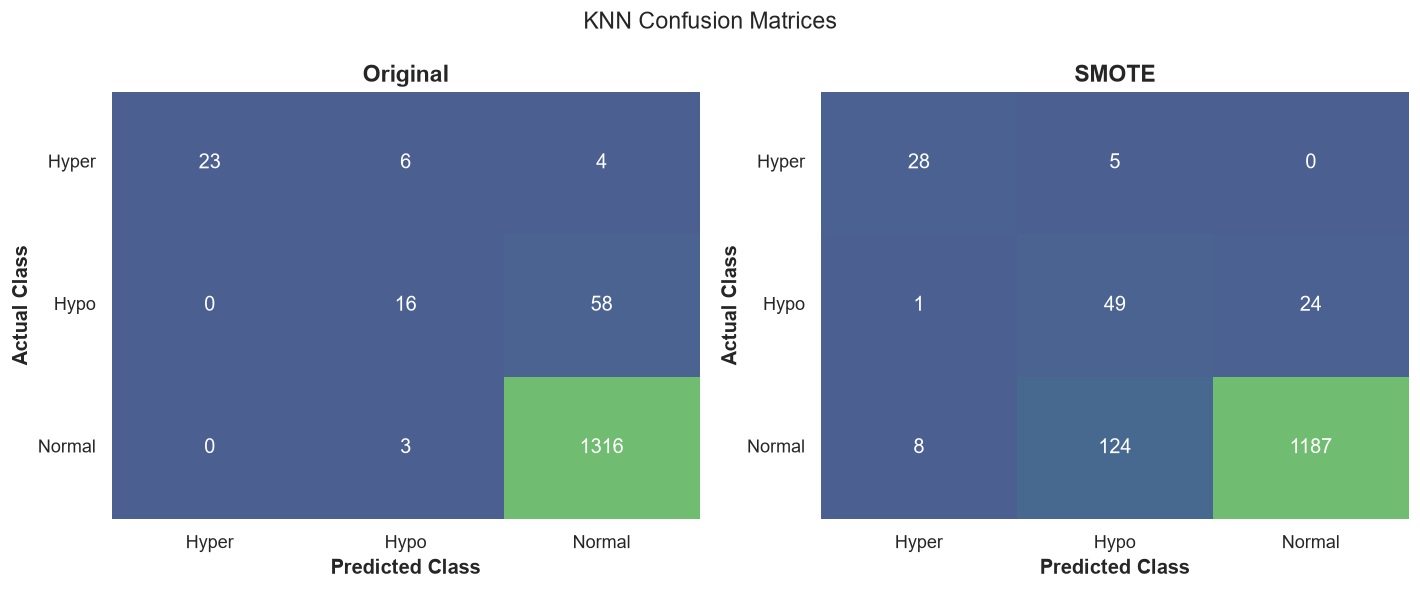

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (strategy, y_pred) in zip(axes, knn_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "KNN Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

SMOTE substantially improves KNN's detection of minority classes, particularly Hypothyroidism, increasing correct predictions from 16 to 49. However, this comes at the cost of more Normal cases being misclassified, explaining the decline in overall Accuracy. Overall, SMOTE improves class balance but does not substantially improve Macro F1 performance.

#### 5.3.6 XGBoost

XGBoost is a gradient boosting algorithm that sequentially combines multiple decision trees to improve predictive performance by correcting errors made by previous trees. As a tree-based algorithm, XGBoost does not require feature scaling. The Original, Class-Weighted, and SMOTE strategies are evaluated to assess its performance under different approaches to class imbalance.

In [92]:
# XGBoost variants
xgb_models = {
    "Original": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ),

    "Class Weighted": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ),

    "SMOTE": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

# Store predictions
xgb_predictions = {}

for strategy, model in xgb_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote
        y_fit = y_train_smote

        model.fit(X_fit, y_fit - 1)

    elif strategy == "Class Weighted":
        X_fit = X_train
        y_fit = y_train

        sample_weights = y_fit.map(class_weights)

        model.fit(
            X_fit,
            y_fit - 1,
            sample_weight=sample_weights
        )

    else:
        X_fit = X_train
        y_fit = y_train

        model.fit(X_fit, y_fit - 1)

    # Convert XGBoost predictions from 0,1,2 back to 1,2,3
    predictions = model.predict(X_test) + 1

    results = {
        "Model": "XGBoost",
        "Strategy": strategy,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, predictions, average="macro", zero_division=0
        )
    }

    model_results.append(results)
    xgb_predictions[strategy] = predictions


# Compare XGBoost variants
xgb_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "XGBoost"
])

xgb_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,XGBoost,Original,0.9951,0.9785,0.9712,0.9785,0.9739
1,XGBoost,Class Weighted,0.9986,0.9995,0.9912,0.9995,0.9953
2,XGBoost,SMOTE,0.9965,0.9804,0.9862,0.9804,0.9832


XGBoost demonstrates excellent performance across all three strategies. Class Weighting achieves the strongest results, with the highest Accuracy (99.86%), Balanced Accuracy (0.9995), and Macro F1-score (0.9953). Although SMOTE improves upon the Original model's Macro F1-score, it does not outperform Class Weighting. Overall, Class-Weighted XGBoost is the best-performing XGBoost variant.

XGBoost Confusion Matrices

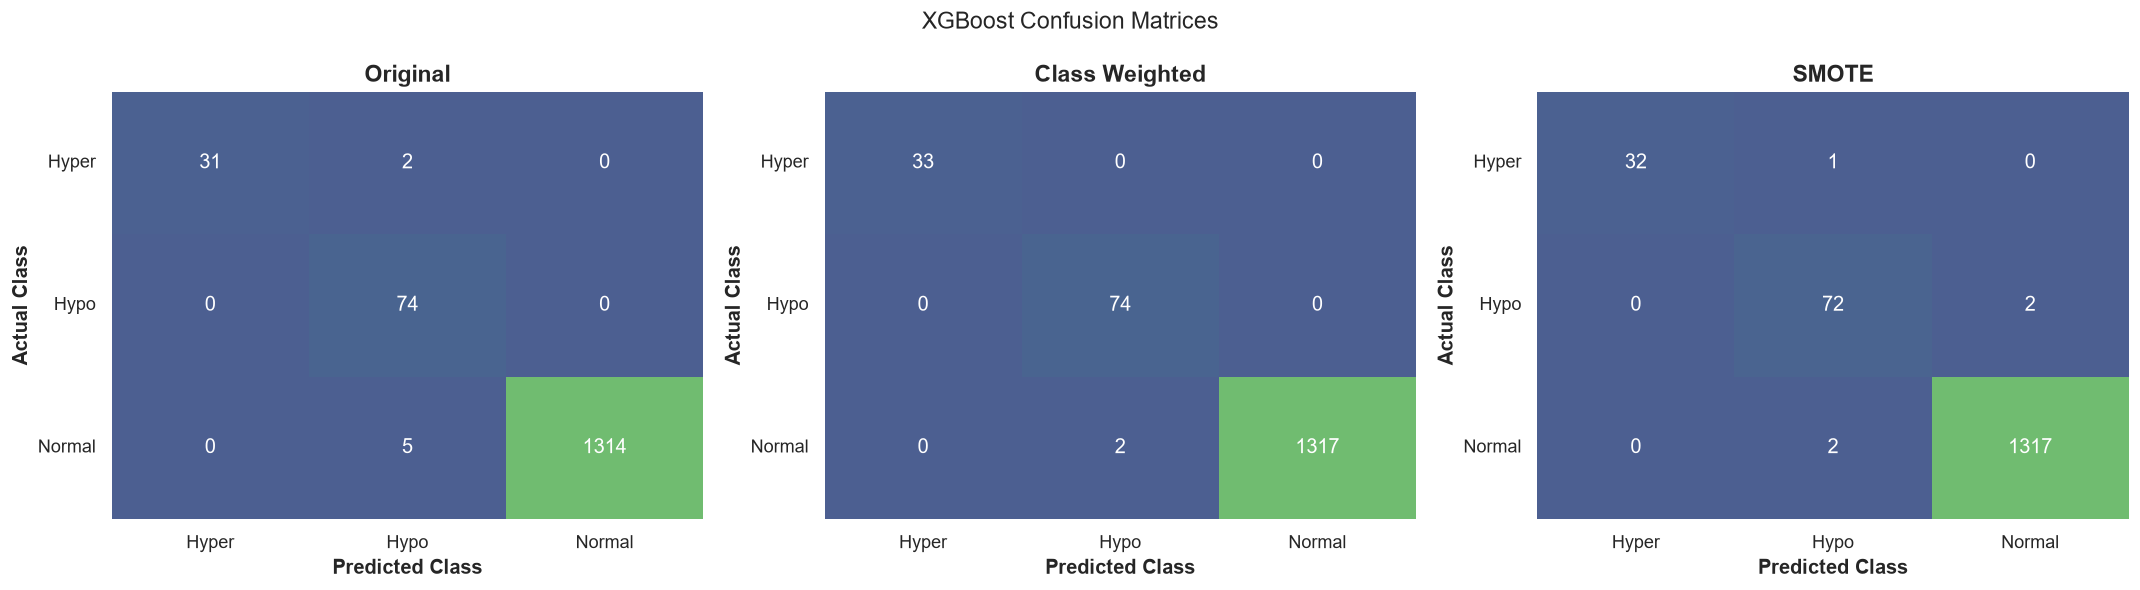

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, xgb_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "XGBoost Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

Class-Weighted XGBoost performs best, correctly identifying all Hyperthyroid and Hypothyroid cases, with only two Normal cases misclassified as Hypothyroid. The Original and SMOTE variants also perform strongly but make slightly more errors. Overall, class weighting provides the most balanced and accurate XGBoost performance.

#### 5.3.7 LightGBM

LightGBM is a gradient boosting algorithm that builds decision trees sequentially to improve predictive performance. Its leaf-wise tree growth strategy can provide efficient and accurate classification, particularly for complex datasets. The Original, Class-Weighted, and SMOTE strategies are evaluated to assess the effect of class imbalance handling.

In [100]:
# LightGBM variants
model_results = [
    result for result in model_results
    if result["Model"] != "LightGBM"
]
lgbm_models = {
    "Original": LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),

    "Class Weighted": LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    ),

    "SMOTE": LGBMClassifier(
        random_state=42,
        verbosity=-1
    )
}

# Store predictions
lgbm_predictions = {}

# Train and evaluate
for strategy, model in lgbm_models.items():

    if strategy == "SMOTE":
        X_fit = X_train_smote
        y_fit = y_train_smote
    else:
        X_fit = X_train
        y_fit = y_train

    model.fit(X_fit, y_fit)

    results, predictions = evaluate_model(
        model,
        X_test,
        y_test,
        "LightGBM",
        strategy
    )

    model_results.append(results)
    lgbm_predictions[strategy] = predictions

# Compare LightGBM variants
lgbm_comparison = pd.DataFrame([
    result for result in model_results
    if result["Model"] == "LightGBM"
])

lgbm_comparison.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,LightGBM,Original,0.9979,0.9950,0.9909,0.9950,0.9929
1,LightGBM,Class Weighted,0.9986,0.9995,0.9912,0.9995,0.9953
2,LightGBM,SMOTE,0.9965,0.9649,0.9863,0.9649,0.9749


LightGBM demonstrates excellent performance across all strategies. The Class-Weighted variant achieves the strongest results, with 99.86% Accuracy, 0.9995 Balanced Accuracy, and 0.9953 Macro F1. The Original model also performs exceptionally well, while SMOTE slightly reduces performance. Overall, Class Weighting is the most effective imbalance strategy for LightGBM.

LightGBM Confusion Matrices

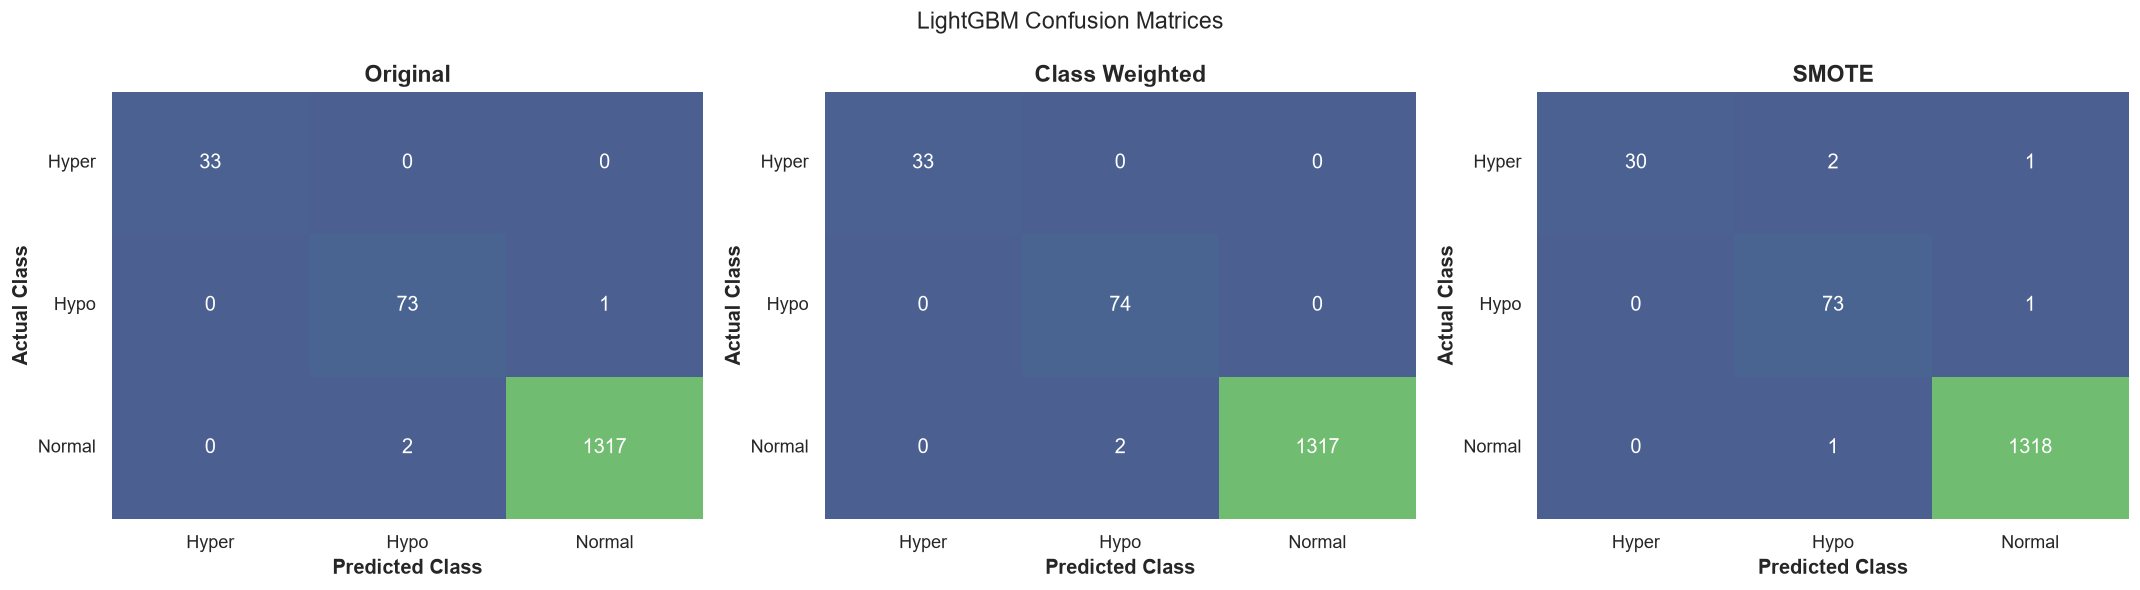

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, y_pred) in zip(axes, lgbm_predictions.items()):

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[1, 2, 3]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(strategy)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticklabels(["Hyper", "Hypo", "Normal"])
    ax.set_yticklabels(
        ["Hyper", "Hypo", "Normal"],
        rotation=0
    )

plt.suptitle(
    "LightGBM Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

LightGBM performs exceptionally well across all strategies. The Class-Weighted model correctly identifies all Hyperthyroid and Hypothyroid cases, with only two Normal cases misclassified as Hypothyroid. SMOTE introduces slightly more minority-class errors, confirming that Class Weighting provides the strongest and most balanced LightGBM performance

### 5.4 Model Performance Comparison

Following individual model evaluation, the performance of all classification algorithms and class-imbalance strategies was compared. Given the substantial class imbalance in the target variable, Macro F1-score and Balanced Accuracy were prioritized over overall Accuracy when identifying the strongest model.

In [102]:

final_results = (
    pd.DataFrame(model_results)
    .drop_duplicates(
        subset=["Model", "Strategy"],
        keep="last"
    )
    .reset_index(drop=True)
)

# Rank models by Macro F1
final_results = final_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_results.round(4)

,Model,Strategy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,XGBoost,Class Weighted,0.9986,0.9995,0.9912,0.9995,0.9953
1,LightGBM,Class Weighted,0.9986,0.9995,0.9912,0.9995,0.9953
2,Decision Tree,Class Weighted,0.9993,0.9899,0.9997,0.9899,0.9947
3,LightGBM,Original,0.9979,0.9950,0.9909,0.9950,0.9929
4,Decision Tree,SMOTE,0.9979,0.9851,0.9950,0.9851,0.9900
5,Random Forest,SMOTE,0.9972,0.9990,0.9772,0.9990,0.9879
6,Decision Tree,Original,0.9972,0.9849,0.9906,0.9849,0.9877
7,Random Forest,Class Weighted,0.9965,0.9987,0.9731,0.9987,0.9856
8,Random Forest,Original,0.9979,0.9894,0.9811,0.9894,0.9852
9,XGBoost,SMOTE,0.9965,0.9804,0.9862,0.9804,0.9832


Overall, the tree-based ensemble models substantially outperform Logistic Regression, SVM, and KNN. Class-Weighted XGBoost and Class-Weighted LightGBM jointly achieve the highest Macro F1-score (0.9953) and Balanced Accuracy (0.9995), indicating near-perfect performance across all three diagnostic classes. The Class-Weighted Decision Tree follows closely with a Macro F1-score of 0.9947. In contrast, the Original Logistic Regression records the lowest Macro F1-score (0.6930), highlighting the effect of class imbalance on simpler models. Overall, class weighting is particularly effective for the strongest-performing models, while SMOTE provides greater benefits to Logistic Regression, SVM, and KNN.

#### 5.4.1 Comparison of Models Perormance

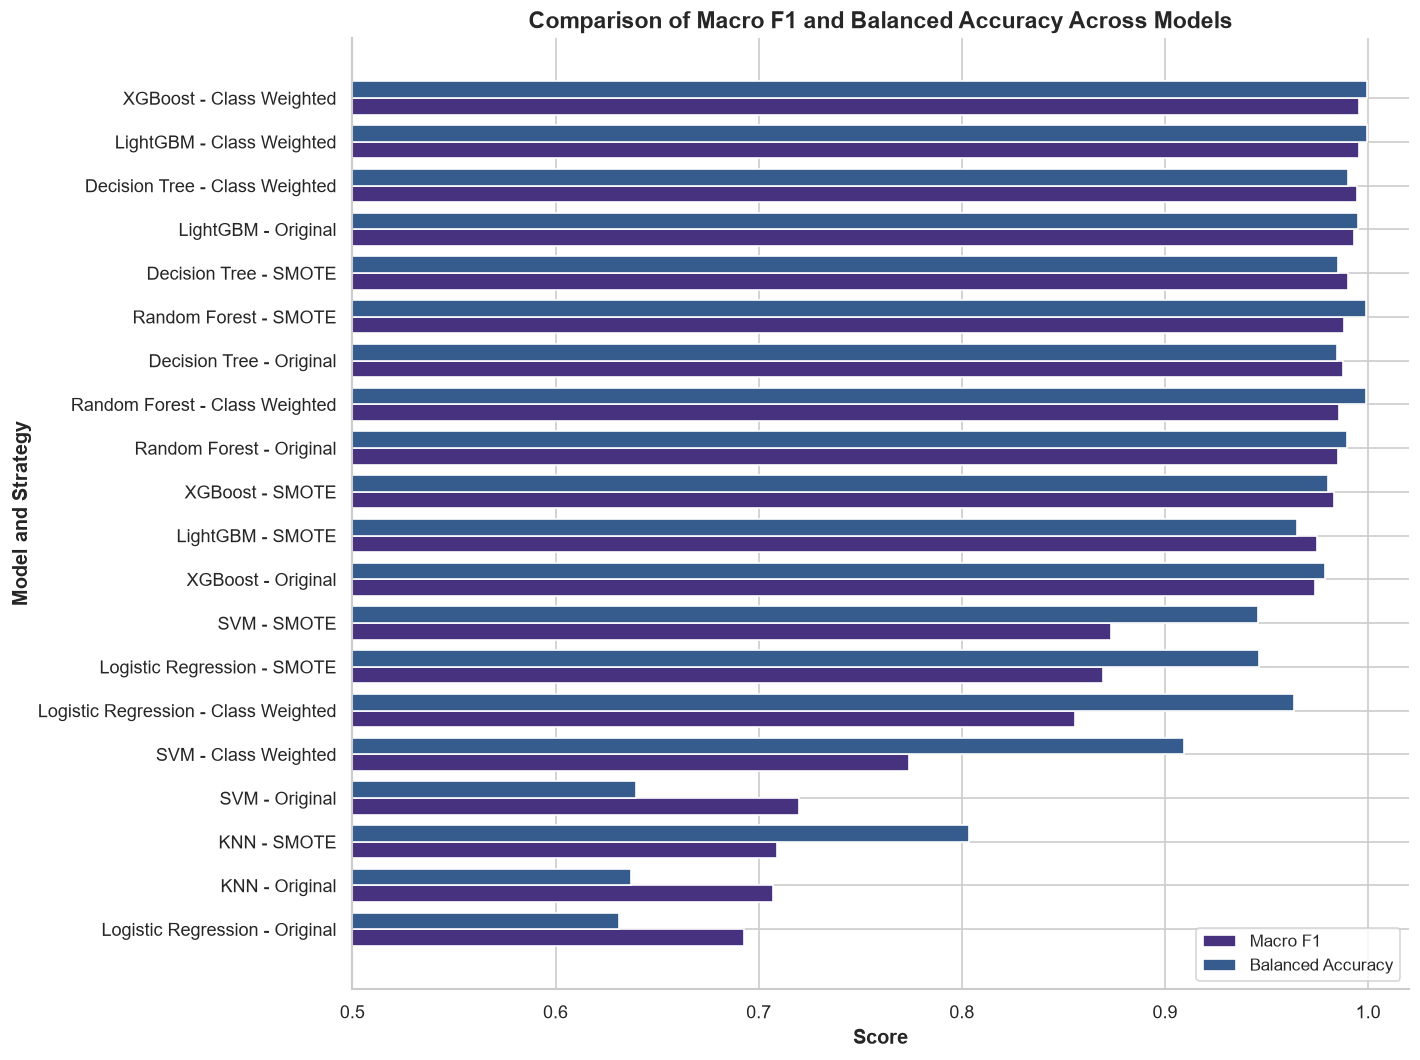

In [103]:

plot_results = final_results.copy()

plot_results["Model-Strategy"] = (
    plot_results["Model"] + " - " + plot_results["Strategy"]
)

# Keep ranking based on Macro F1
plot_results = plot_results.sort_values(
    "Macro F1",
    ascending=True
)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

y = np.arange(len(plot_results))
height = 0.38

ax.barh(
    y - height/2,
    plot_results["Macro F1"],
    height,
    label="Macro F1"
)

ax.barh(
    y + height/2,
    plot_results["Balanced Accuracy"],
    height,
    label="Balanced Accuracy"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_results["Model-Strategy"])

ax.set_xlabel("Score")
ax.set_ylabel("Model and Strategy")
ax.set_title(
    "Comparison of Macro F1 and Balanced Accuracy Across Models"
)

ax.set_xlim(0.5, 1.02)
ax.legend()

plt.tight_layout()
plt.show()

The comparison shows a clear advantage for tree-based models. Class-Weighted XGBoost and LightGBM achieve the strongest overall performance, both recording a Macro F1-score of 0.9953 and Balanced Accuracy of 0.9995. Decision Tree and Random Forest variants also perform strongly, while Logistic Regression, SVM, and KNN show comparatively lower balanced performance. Overall, class weighting is particularly effective for the highest-performing models.

### 5.5 Final Model Selection

Both Class-Weighted XGBoost and Class-Weighted LightGBM produced identical test-set metrics:
| Model                     | Accuracy | Balanced Accuracy | Macro F1 |
| ------------------------- | -------: | ----------------: | -------: |
| XGBoost – Class Weighted  |   0.9986 |            0.9995 |   0.9953 |
| LightGBM – Class Weighted |   0.9986 |            0.9995 |   0.9953 |


#### 5.5.1 Cross-Validation of Top Models

In [108]:
# Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_scores = []
lgbm_scores = []

for train_idx, val_idx in cv.split(X_train, y_train):

    # Split each fold
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    
    # XGBoost - Class Weighted
    

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_tr
    )

    xgb_cv = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )

    xgb_cv.fit(
        X_tr,
        y_tr - 1,
        sample_weight=sample_weights
    )

    xgb_pred = xgb_cv.predict(X_val) + 1

    xgb_scores.append(
        f1_score(
            y_val,
            xgb_pred,
            average="macro"
        )
    )

    
    # LightGBM - Class Weighted
    

    lgbm_cv = LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbosity=-1
    )

    lgbm_cv.fit(
        X_tr,
        y_tr
    )

    lgbm_pred = lgbm_cv.predict(X_val)

    lgbm_scores.append(
        f1_score(
            y_val,
            lgbm_pred,
            average="macro"
        )
    )

# Cross-validation summary
cv_results = pd.DataFrame({
    "Model": [
        "XGBoost - Class Weighted",
        "LightGBM - Class Weighted"
    ],
    "Mean CV Macro F1": [
        np.mean(xgb_scores),
        np.mean(lgbm_scores)
    ],
    "Std CV Macro F1": [
        np.std(xgb_scores),
        np.std(lgbm_scores)
    ]
})

cv_results.round(4)

,Model,Mean CV Macro F1,Std CV Macro F1
0,XGBoost - Class Weighted,0.9724,0.0101
1,LightGBM - Class Weighted,0.9751,0.0095


Both models demonstrate strong and stable cross-validation performance. However, Class-Weighted LightGBM achieves a slightly higher mean Macro F1-score (0.9751) than Class-Weighted XGBoost (0.9724). LightGBM also records slightly lower variability across folds (0.0095 vs. 0.0101), indicating marginally more consistent performance. Therefore, Class-Weighted LightGBM is selected as the preferred model based on its stronger and more stable cross-validation performance.

### 5.6 Hyperparameter Tuning

Following baseline model comparison and cross-validation, Class-Weighted LightGBM was selected for further optimization. Hyperparameter tuning is performed on the training data using stratified cross-validation, with Macro F1-score used as the optimization metric. This aims to improve model performance while maintaining balanced classification across all three thyroid diagnosis classes.

In [ ]:
# Parameter search space
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 50, 70],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Initialize Class-Weighted LightGBM
lgbm_tuning = LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

# Stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized hyperparameter search
random_search = RandomizedSearchCV(
    estimator=lgbm_tuning,
    param_distributions=param_grid,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Tune using training data only
random_search.fit(X_train, y_train)



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on thi

In [113]:
best_params_df = pd.DataFrame(
    random_search.best_params_.items(),
    columns=["Hyperparameter", "Best Value"]
)

best_params_df

,Hyperparameter,Best Value
0,subsample,0.7000
1,num_leaves,15.0000
2,n_estimators,300.0000
3,min_child_samples,30.0000
4,max_depth,-1.0000
5,learning_rate,0.0500
6,colsample_bytree,0.7000


In [114]:
print(f"Best CV Macro F1: {random_search.best_score_:.4f}")


Best CV Macro F1: 0.9793


Hyperparameter tuning improved the cross-validation Macro F1-score from 0.9751 for the baseline Class-Weighted LightGBM to 0.9793 for the tuned model. This indicates a modest improvement in predictive performance and supports using the optimized LightGBM configuration for final evaluation.
| Model                            | CV Macro F1 |
| -------------------------------- | ----------: |
| Baseline Class-Weighted LightGBM |      0.9751 |
| Tuned Class-Weighted LightGBM    |      0.9793 |
| Improvement                      |     +0.0042 |


### 5.7 Final Model Evaluation

Following hyperparameter tuning, the optimized Class-Weighted LightGBM model is evaluated on the untouched test set. Its performance is compared with the baseline Class-Weighted LightGBM to determine whether the improvement observed during cross-validation translates to unseen data.

In [115]:
# Retrieve the best tuned LightGBM model
final_model = random_search.best_estimator_

# Generate test predictions
y_pred_final = final_model.predict(X_test)

# Calculate final performance metrics
final_metrics = {
    "Model": "Tuned LightGBM",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_final),
    "Macro Precision": precision_score(
        y_test, y_pred_final, average="macro", zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test, y_pred_final, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        y_test, y_pred_final, average="macro", zero_division=0
    )
}

pd.DataFrame([final_metrics]).round(4)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Tuned LightGBM,0.9986,0.9995,0.9912,0.9995,0.9953


#### 5.7.2 Baseline vs Tuned LightGBM

In [116]:
# Baseline Class-Weighted LightGBM results
baseline_lgbm = final_results[
    (final_results["Model"] == "LightGBM") &
    (final_results["Strategy"] == "Class Weighted")
].iloc[0]

comparison = pd.DataFrame({
    "Model": [
        "Baseline Class-Weighted LightGBM",
        "Tuned Class-Weighted LightGBM"
    ],
    "Accuracy": [
        baseline_lgbm["Accuracy"],
        final_metrics["Accuracy"]
    ],
    "Balanced Accuracy": [
        baseline_lgbm["Balanced Accuracy"],
        final_metrics["Balanced Accuracy"]
    ],
    "Macro Precision": [
        baseline_lgbm["Macro Precision"],
        final_metrics["Macro Precision"]
    ],
    "Macro Recall": [
        baseline_lgbm["Macro Recall"],
        final_metrics["Macro Recall"]
    ],
    "Macro F1": [
        baseline_lgbm["Macro F1"],
        final_metrics["Macro F1"]
    ]
})

comparison.round(4)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline Class-Weighted LightGBM,0.9986,0.9995,0.9912,0.9995,0.9953
1,Tuned Class-Weighted LightGBM,0.9986,0.9995,0.9912,0.9995,0.9953


The tuned and baseline Class-Weighted LightGBM models achieve identical test performance, with 99.86% Accuracy, 0.9995 Balanced Accuracy, and 0.9953 Macro F1. Although tuning improved cross-validation Macro F1 from 0.9751 to 0.9793, it did not further improve test-set performance. The tuned model is retained as the final model because it demonstrated stronger cross-validation performance while maintaining the baseline model's excellent performance on unseen data.

Tuned LightGBM Confusion Matrix

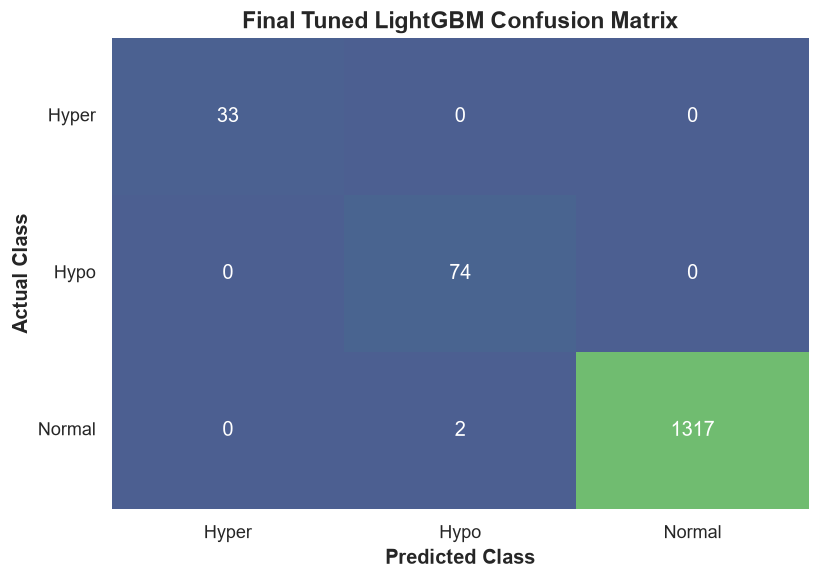

In [117]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[1, 2, 3]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    cbar=False
)

plt.title("Final Tuned LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0.5, 1.5, 2.5],
    ["Hyper", "Hypo", "Normal"]
)

plt.yticks(
    [0.5, 1.5, 2.5],
    ["Hyper", "Hypo", "Normal"],
    rotation=0
)

plt.tight_layout()
plt.show()

The final tuned LightGBM model demonstrates excellent classification performance. It correctly classifies all 33 Hyperthyroid cases and all 74 Hypothyroid cases. Only two Normal cases are misclassified as Hypothyroid, while 1,317 Normal cases are correctly identified. This confirms the model's strong ability to distinguish all three thyroid diagnostic classes despite the substantial class imbalance.

## Model Explainability

Model explainability was conducted to understand the key features influencing predictions made by the final tuned LightGBM model.

#### 6.1 Feature Importance

Feature importance analysis was conducted to identify the predictors that contributed most strongly to the final tuned LightGBM model's classification decisions.

In [118]:
# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,FTI,2307
1,TSH,2243
2,T3,2238
3,TT4,2153
4,T4U,1345
5,age,1125
6,on_thyroxine,432
7,thyroid_surgery,325
8,I131_treatment,127
9,on_antithyroid_medication,104


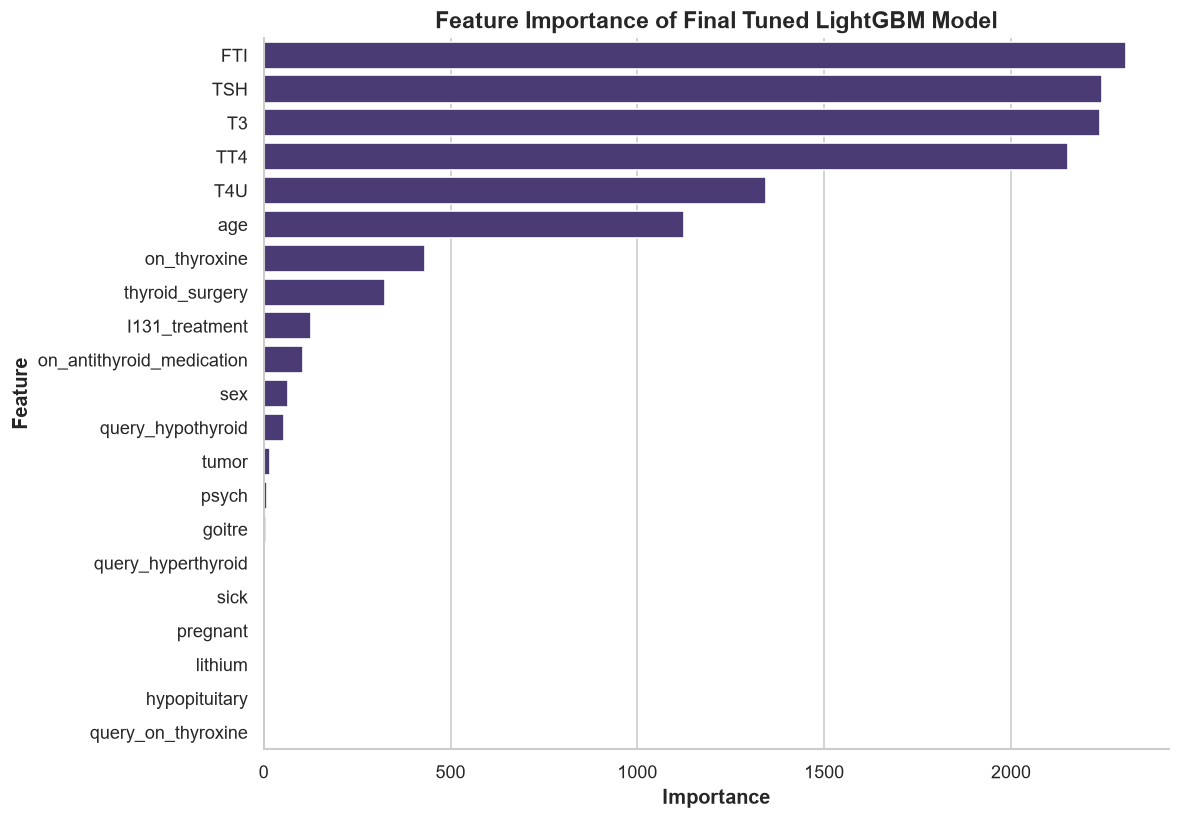

In [119]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance of Final Tuned LightGBM Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The feature importance analysis shows that FTI, TSH, T3, and TT4 are the strongest contributors to the final LightGBM model, followed by T4U and age. Clinical binary variables contribute comparatively less to the model's predictions. Overall, the model relies predominantly on thyroid hormone-related measurements for classification, which is consistent with the patterns identified during EDA.

## 7. Final Findings and Conclusion

This section summarizes the key findings and insights obtained from the exploratory analysis, model development, evaluation, and explainability stages. It also highlights the study limitations and presents the overall conclusion.

### 7.1 Key Findings

- The target variable exhibited substantial class imbalance, with Normal cases representing approximately 92.5% of the dataset, compared with about 5.2% Hypothyroid and 2.3% Hyperthyroid cases.

- Class imbalance negatively affected some models, particularly Logistic Regression, SVM, and KNN, despite their relatively high overall accuracy.

- Tree-based models consistently demonstrated stronger classification performance than the linear and distance-based models.

- Class weighting was particularly effective for Decision Tree, XGBoost, and LightGBM, while SMOTE produced greater improvements for Logistic Regression and SVM.

- Class-Weighted XGBoost and LightGBM achieved the strongest baseline performance, both recording a Macro F1-score of 0.9953 and Balanced Accuracy of 0.9995.

- Cross-validation identified Class-Weighted LightGBM as slightly more stable, achieving a mean Macro F1-score of 0.9751 compared with 0.9724 for XGBoost.

- Hyperparameter tuning improved the LightGBM cross-validation Macro F1-score from 0.9751 to 0.9793.

- The final tuned LightGBM achieved 99.86% Accuracy, 0.9995 Balanced Accuracy, and 0.9953 Macro F1 on the test set.

- The final model correctly classified all Hyperthyroid and Hypothyroid cases, with only two Normal cases misclassified as Hypothyroid.

- FTI, TSH, T3, TT4, and T4U emerged as the most influential predictors in the final LightGBM model.

### 7.2 Key Insights

- High overall accuracy did not necessarily indicate balanced model performance. Macro F1-score and Balanced Accuracy provided a more reliable assessment of performance across the three diagnosis classes.

- The effectiveness of imbalance handling depended on the classification algorithm. No single imbalance strategy performed best across all models.

- Class weighting provided particularly strong results for the highest-performing tree-based models without requiring synthetic observations.

- SMOTE substantially improved minority-class detection for Logistic Regression and SVM but offered limited additional benefit for stronger tree-based models.

- Tree-based models were better able to capture the relationships between the predictors and thyroid diagnosis than the linear and distance-based approaches evaluated.

- Thyroid laboratory measurements contributed substantially more to classification than most binary clinical variables.

- Hyperparameter tuning improved cross-validation performance but did not change test-set performance, indicating that the baseline LightGBM model was already highly effective.

### 7.3 Limitations

- The dataset contains relatively few Hyperthyroid and Hypothyroid observations compared with Normal cases.

- The model was developed and evaluated using a single dataset and has not been externally validated on an independent patient population.

- Synthetic observations generated through SMOTE may not fully represent real clinical patient profiles.

- The near-perfect performance of the final model should be interpreted cautiously until validated using independent datasets.

- Feature importance indicates the predictive contribution of variables but does not establish causal relationships between these features and thyroid disease.

- The developed model is intended for classification research and should not be considered a replacement for professional clinical diagnosis.

### 7.4 Conclusion

This study demonstrates the importance of addressing class imbalance when developing machine learning models for multiclass thyroid disease classification. Among the evaluated algorithms, tree-based models demonstrated the strongest overall performance, with Class-Weighted LightGBM ultimately selected based on its high predictive performance and stable cross-validation results.

Following hyperparameter tuning, the final LightGBM model achieved a Macro F1-score of 0.9953 and Balanced Accuracy of 0.9995 on the test set. FTI, TSH, T3, TT4, and T4U were identified as the most influential predictors, emphasizing the importance of thyroid-related laboratory measurements in classification.

Overall, the findings demonstrate the potential of machine learning for distinguishing Hyperthyroid, Hypothyroid, and Normal cases. However, external validation on independent and more diverse datasets is recommended before considering broader practical or clinical application.

## 8 Model Deployment

### 8.1 Save the Final Model

In [126]:
import joblib

joblib.dump(final_model, "thyroid_lightgbm_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [127]:
joblib.dump(
    X_train.columns.tolist(),
    "thyroid_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [128]:
import numpy
import sklearn
import lightgbm
import joblib

print("numpy:", numpy.__version__)
print("scikit-learn:", sklearn.__version__)
print("lightgbm:", lightgbm.__version__)
print("joblib:", joblib.__version__)

numpy: 2.4.6
scikit-learn: 1.9.0
lightgbm: 4.7.0
joblib: 1.5.3


## References

1. American Thyroid Association. Thyroid function tests [Internet]. Falls Church (VA): American Thyroid Association; [cited 2026 Aug 20]. Available from: American Thyroid Association – Thyroid Function Tests

2. Van Uytfanghe K, Ehrenkranz J, Halsall D, Hoff K, Loh TP, Spencer CA, et al. Thyroid stimulating hormone and thyroid hormones (triiodothyronine and thyroxine): an American Thyroid Association-commissioned review of current clinical and laboratory status. Thyroid. 2023;33(9).

3. Biondi B, Cooper DS. The clinical significance of subclinical thyroid dysfunction. Endocr Rev. 2008;29(1):76-131.

4. Tessler FN, Middleton WD, Grant EG, Hoang JK, Berland LL, Teefey SA, et al. ACR Thyroid Imaging, Reporting and Data System (TI-RADS): white paper of the ACR TI-RADS Committee. J Am Coll Radiol. 2017;14(5):587-595.

5. Liu J, Wang Y, Da D, Zheng M. Hyperfunctioning thyroid carcinoma: a systematic review. Mol Clin Oncol. 2019;11(6):535-550. doi:10.3892/mco.2019.1927.

6. UCI Machine Learning Repository. Thyroid Disease [Internet]. Irvine (CA): University of California, Irvine; [cited 2026 Aug 20]. Available from: UCI Thyroid Disease dataset